# Preprocess & EDA — E-Commerce Fashion Operations (Vietnam)

## Mục tiêu
- Nạp toàn bộ dữ liệu trong thư mục `data/` và **chuẩn hoá kiểu dữ liệu** (đặc biệt là các cột ngày).
- Kiểm tra **chất lượng dữ liệu**: missing / duplicates / outliers / ràng buộc business.
- Tạo **bảng phân tích (join nhiều bảng)** để EDA theo 4 tầng: **Descriptive → Diagnostic → Predictive → Prescriptive**.
- Chuẩn bị bảng/aggregate để dùng cho **Tableau + Power BI** (nếu cần).

## Tài liệu tham chiếu
- `DATA.md`: schema, relationships, business rules & derived metrics
- `INSTRUCTION.md`: rubric chấm điểm EDA (4-tier + visualization standards)
- `PLAN.md`: checklist EDA (1 biến / 2 biến / multi / time series / geography)

> Gợi ý: Sau mỗi biểu đồ, viết ngắn gọn 4 gạch đầu dòng theo 4 tầng (Descriptive/Diagnostic/Predictive/Prescriptive) để tối đa điểm.

Link tham khảo (nếu cần): https://gemini.google.com/share/c624fa5f088b

In [63]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, PercentFormatter
import seaborn as sns
from IPython.display import display

# Optional stats helpers (fallbacks provided where possible)
try:
    from scipy import stats
except Exception:
    stats = None

# -----------------------------
# Global config
# -----------------------------
np.random.seed(42)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Competition-ready visual defaults
sns.set_theme(style="whitegrid", context="talk", palette="colorblind")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "figure.dpi": 130,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "axes.titlepad": 12,
        "axes.formatter.useoffset": False,
    }
)

DATA_DIR = Path("data")
assert DATA_DIR.exists(), f"Missing data folder: {DATA_DIR.resolve()}"

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# -----------------------------
# Format helpers (numbers / percent)
# -----------------------------

def _fmt_thousands(x: float, pos: int) -> str:
    try:
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return ""
        return f"{x:,.0f}"
    except Exception:
        return str(x)


THOUSANDS_FMT = FuncFormatter(_fmt_thousands)
PCT_FMT_0 = PercentFormatter(xmax=1.0, decimals=0)
PCT_FMT_1 = PercentFormatter(xmax=1.0, decimals=1)


def format_axis_thousands(ax: plt.Axes, axis: str = "y") -> plt.Axes:
    """Format axis ticks with thousands separators."""
    axis = axis.lower()
    if axis in {"x", "both"}:
        ax.xaxis.set_major_formatter(THOUSANDS_FMT)
    if axis in {"y", "both"}:
        ax.yaxis.set_major_formatter(THOUSANDS_FMT)
    return ax


def beautify_ax(ax: plt.Axes, *, grid: bool = True) -> plt.Axes:
    """Consistent finishing touches for most plots."""
    if grid:
        ax.grid(True, which="major", alpha=0.25)
    ax.tick_params(axis="both", labelsize=11)
    sns.despine(ax=ax)
    return ax


# -----------------------------
# Helper utilities
# -----------------------------

def _parse_dates_inplace(df: pd.DataFrame) -> pd.DataFrame:
    """Parse columns that look like dates (safe, coercing errors to NaT)."""
    for col in df.columns:
        col_lower = str(col).lower()
        if col_lower == "date" or col_lower.endswith("_date") or col_lower.endswith("date"):
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def _strip_object_columns_inplace(df: pd.DataFrame) -> pd.DataFrame:
    """Trim whitespace + normalize empty strings to NA to reduce categorical 'noise'."""
    obj_cols = df.select_dtypes(include=["object"]).columns
    for col in obj_cols:
        cleaned = df[col].astype("string").str.strip()
        df[col] = cleaned.replace({"": pd.NA})
    return df


def profile_table(df: pd.DataFrame, table_name: str) -> pd.DataFrame:
    """Lightweight column-level profile for quick EDA."""
    out = pd.DataFrame(
        {
            "table": table_name,
            "column": df.columns,
            "dtype": [str(t) for t in df.dtypes],
            "n": len(df),
            "missing_n": df.isna().sum().values,
            "missing_pct": (df.isna().mean() * 100).values,
            "nunique": df.nunique(dropna=True).values,
        }
    )

    # Add a small sample to help identify noise / unexpected categories
    samples = []
    for col in df.columns:
        series = df[col]
        # Sample 3 non-null values for quick inspection
        vals = series.dropna().astype(str).unique()[:3]
        samples.append(", ".join(vals))
    out["sample_values"] = samples

    return out.sort_values(["missing_pct", "nunique"], ascending=[False, False]).reset_index(drop=True)


def print_section(title: str) -> None:
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)


## 0. Data loading & preprocessing

- Load toàn bộ file `.csv` trong `data/`.
- Chuẩn hoá **cột ngày** sang `datetime`.
- Giảm **noise** bằng cách trim whitespace cho cột dạng text.

> Output mong muốn: `tables` (dict) chứa toàn bộ DataFrame theo tên file.

In [64]:
def load_all_tables(data_dir: Path) -> dict[str, pd.DataFrame]:
    """Load all CSVs from data_dir into a dict keyed by filename stem."""
    tables: dict[str, pd.DataFrame] = {}

    csv_paths = sorted(data_dir.glob("*.csv"))
    if not csv_paths:
        raise FileNotFoundError(f"No .csv files found in: {data_dir.resolve()}")

    for csv_path in csv_paths:
        name = csv_path.stem
        df = pd.read_csv(csv_path)

        # Basic cleaning
        df = _parse_dates_inplace(df)
        df = _strip_object_columns_inplace(df)

        tables[name] = df

    return tables


tables = load_all_tables(DATA_DIR)
print_section("Loaded tables")
for name, df in tables.items():
    print(f"{name:16s} shape={df.shape}")

# Convenience variables (use .get to avoid KeyError if a file is missing)
products = tables.get("products")
customers = tables.get("customers")
geography = tables.get("geography")
promotions = tables.get("promotions")
orders = tables.get("orders")
order_items = tables.get("order_items")
payments = tables.get("payments")
shipments = tables.get("shipments")
returns = tables.get("returns")
reviews = tables.get("reviews")
inventory = tables.get("inventory")
web_traffic = tables.get("web_traffic")
sales = tables.get("sales")



# Quick sanity: show columns for the most important tables
print_section("Key tables — columns")
# for name in ["orders", "order_items", "products", "customers", "payments", "shipments", "returns", "sales", "web_traffic"]:
for name in ["products", "customers", "geography", "promotions", "orders", "order_items", "payments", "shipments", "returns", "reviews", "inventory", "web_traffic", "sales"]:
    df = tables.get(name)
    if df is None:
        continue
    print(f"\n{name}: {list(df.columns)}")


Loaded tables
customers        shape=(121930, 7)
geography        shape=(39948, 4)
inventory        shape=(60247, 17)
order_items      shape=(714669, 7)
orders           shape=(646945, 8)
payments         shape=(646945, 4)
products         shape=(2412, 8)
promotions       shape=(50, 10)
returns          shape=(39939, 7)
reviews          shape=(113551, 7)
sales            shape=(3833, 3)
sample_submission shape=(548, 3)
shipments        shape=(566067, 4)
web_traffic      shape=(3652, 7)

Key tables — columns

products: ['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']

customers: ['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group', 'acquisition_channel']

geography: ['zip', 'city', 'region', 'district']

promotions: ['promo_id', 'promo_name', 'promo_type', 'discount_value', 'start_date', 'end_date', 'applicable_category', 'promo_channel', 'stackable_flag', 'min_order_value']

orders: ['order_id', 'order_date', 'customer_id', 'zip', 

## 1. Data quality & integrity checks

Phần này nhằm đảm bảo dữ liệu đáng tin trước khi EDA sâu:
- Missing data (tỷ lệ missing theo bảng/cột)
- Duplicate rows / duplicate keys
- Kiểm tra **Primary Key / Composite Key** theo mô tả trong `DATA.md`
- Kiểm tra **Foreign Key validity** (tỷ lệ orphan keys)
- Kiểm tra **business rules** (ví dụ: `cogs < price`, công thức discount, start_date ≤ end_date)

> Output mong muốn: một bảng profile tổng hợp + danh sách issue cần chú ý.

In [65]:
# -----------------------------
# 1) Column profiling (Missing / dtype / nunique)
# -----------------------------
print_section("Column profiling")
profiles = []
for name, df in tables.items():
    profiles.append(profile_table(df, name))

profile_all = pd.concat(profiles, ignore_index=True)
profile_all.head(10)

# Save for quick review / Tableau-PowerBI ingestion
profile_path = OUTPUT_DIR / "column_profile_all_tables.csv"
profile_all.to_csv(profile_path, index=False)
print(f"Saved column profile to: {profile_path}")

# -----------------------------
# 2) Missingness hotspots
# -----------------------------
print_section("Missingness hotspots")
(
    profile_all.sort_values(["missing_pct", "nunique"], ascending=[False, False])
    .query("missing_pct > 0")
    .head(25)
)

# -----------------------------
# 3) Duplicates + key integrity
# -----------------------------
print_section("Duplicate rows per table")
dup_rows = []
for name, df in tables.items():
    dup_rows.append({"table": name, "dup_rows": int(df.duplicated().sum()), "n": len(df)})

dup_rows_df = pd.DataFrame(dup_rows).sort_values("dup_rows", ascending=False)
dup_rows_df

EXPECTED_KEYS: dict[str, list[str]] = {
    "products": ["product_id"],
    "customers": ["customer_id"],
    "geography": ["zip"],
    "promotions": ["promo_id"],
    "orders": ["order_id"],
    "order_items": ["order_id", "product_id"],
    "payments": ["order_id"],
    "shipments": ["order_id"],
    "returns": ["return_id"],
    "reviews": ["review_id"],
    "inventory": ["snapshot_date", "product_id"],
    "web_traffic": ["date", "traffic_source"],
    "sales": ["Date"],
}


def check_key(df: pd.DataFrame, key_cols: list[str]) -> dict:
    n = len(df)
    key_df = df[key_cols]
    null_rows = int(key_df.isna().any(axis=1).sum())
    dup_keys = int(df.duplicated(subset=key_cols).sum())
    n_unique = int(df.drop_duplicates(subset=key_cols).shape[0])
    return {
        "n": n,
        "key": "+".join(key_cols),
        "null_key_rows": null_rows,
        "dup_key_rows": dup_keys,
        "unique_ratio": (n_unique / n) if n else np.nan,
    }


print_section("Expected key checks")
key_checks = []
for table_name, key_cols in EXPECTED_KEYS.items():
    df = tables.get(table_name)
    if df is None:
        continue
    missing_cols = [c for c in key_cols if c not in df.columns]
    if missing_cols:
        key_checks.append({"table": table_name, "key": "+".join(key_cols), "error": f"missing cols: {missing_cols}"})
        continue

    row = {"table": table_name} | check_key(df, key_cols)
    key_checks.append(row)

pd.DataFrame(key_checks).sort_values(["dup_key_rows", "null_key_rows"], ascending=False)

# -----------------------------
# 4) Foreign key validity (orphan keys)
# -----------------------------

def fk_orphans(child: pd.DataFrame, child_col: str, parent: pd.DataFrame, parent_col: str, allow_null: bool = True) -> dict:
    """Count child values not found in parent (optionally ignoring nulls)."""
    if allow_null:
        series = child[child_col].dropna()
    else:
        series = child[child_col]

    parent_values = set(parent[parent_col].dropna().unique())
    orphan_mask = ~series.isin(parent_values)
    return {
        "child_col": child_col,
        "parent_col": parent_col,
        "child_n": int(series.shape[0]),
        "orphan_n": int(orphan_mask.sum()),
        "orphan_pct": float(orphan_mask.mean() * 100) if len(series) else np.nan,
    }


print_section("Foreign key checks")
fk_results = []

# Common FK relationships (from DATA.md)
if orders is not None and customers is not None:
    fk_results.append({"relation": "orders.customer_id -> customers.customer_id"} | fk_orphans(orders, "customer_id", customers, "customer_id"))
if orders is not None and geography is not None:
    fk_results.append({"relation": "orders.zip -> geography.zip"} | fk_orphans(orders, "zip", geography, "zip"))
if customers is not None and geography is not None:
    fk_results.append({"relation": "customers.zip -> geography.zip"} | fk_orphans(customers, "zip", geography, "zip"))
if order_items is not None and orders is not None:
    fk_results.append({"relation": "order_items.order_id -> orders.order_id"} | fk_orphans(order_items, "order_id", orders, "order_id"))
if order_items is not None and products is not None:
    fk_results.append({"relation": "order_items.product_id -> products.product_id"} | fk_orphans(order_items, "product_id", products, "product_id"))
if payments is not None and orders is not None:
    fk_results.append({"relation": "payments.order_id -> orders.order_id"} | fk_orphans(payments, "order_id", orders, "order_id"))
if shipments is not None and orders is not None:
    fk_results.append({"relation": "shipments.order_id -> orders.order_id"} | fk_orphans(shipments, "order_id", orders, "order_id"))
if returns is not None and orders is not None:
    fk_results.append({"relation": "returns.order_id -> orders.order_id"} | fk_orphans(returns, "order_id", orders, "order_id"))
if returns is not None and products is not None:
    fk_results.append({"relation": "returns.product_id -> products.product_id"} | fk_orphans(returns, "product_id", products, "product_id"))
if reviews is not None and orders is not None:
    fk_results.append({"relation": "reviews.order_id -> orders.order_id"} | fk_orphans(reviews, "order_id", orders, "order_id"))
if reviews is not None and products is not None:
    fk_results.append({"relation": "reviews.product_id -> products.product_id"} | fk_orphans(reviews, "product_id", products, "product_id"))
if reviews is not None and customers is not None:
    fk_results.append({"relation": "reviews.customer_id -> customers.customer_id"} | fk_orphans(reviews, "customer_id", customers, "customer_id"))

# Promotions are optional in order_items, but when present should exist in promotions table
if order_items is not None and promotions is not None:
    for col in ["promo_id", "promo_id_2"]:
        if col in order_items.columns:
            fk_results.append({"relation": f"order_items.{col} -> promotions.promo_id"} | fk_orphans(order_items, col, promotions, "promo_id", allow_null=True))

pd.DataFrame(fk_results).sort_values("orphan_pct", ascending=False)

# -----------------------------
# 5) Business rule checks
# -----------------------------
print_section("Business rule checks")
issues = []

# (a) Pricing constraint: cogs < price
if products is not None and {"cogs", "price"}.issubset(products.columns):
    bad = products.query("cogs >= price")
    issues.append({"check": "products: cogs < price", "violations": int(len(bad))})
    if len(bad):
        display(bad.head(10))

# (b) Promotions: start_date <= end_date
if promotions is not None and {"start_date", "end_date"}.issubset(promotions.columns):
    bad = promotions[promotions["start_date"] > promotions["end_date"]]
    issues.append({"check": "promotions: start_date <= end_date", "violations": int(len(bad))})

# (c) Shipments: non-negative fee, delivery_date >= ship_date
if shipments is not None and "shipping_fee" in shipments.columns:
    bad = shipments[shipments["shipping_fee"] < 0]
    issues.append({"check": "shipments: shipping_fee >= 0", "violations": int(len(bad))})
if shipments is not None and {"ship_date", "delivery_date"}.issubset(shipments.columns):
    bad = shipments[shipments["delivery_date"] < shipments["ship_date"]]
    issues.append({"check": "shipments: delivery_date >= ship_date", "violations": int(len(bad))})

# (d) Order items: quantity > 0, unit_price >= 0, discount_amount >= 0
if order_items is not None:
    if "quantity" in order_items.columns:
        bad = order_items[order_items["quantity"] <= 0]
        issues.append({"check": "order_items: quantity > 0", "violations": int(len(bad))})
    if "unit_price" in order_items.columns:
        bad = order_items[order_items["unit_price"] < 0]
        issues.append({"check": "order_items: unit_price >= 0", "violations": int(len(bad))})
    if "discount_amount" in order_items.columns:
        bad = order_items[order_items["discount_amount"] < 0]
        issues.append({"check": "order_items: discount_amount >= 0", "violations": int(len(bad))})

issues_df = pd.DataFrame(issues)
issues_df

# (e) Discount formula sanity check (only for rows with exactly 1 promo_id and no promo_id_2)
if (order_items is not None) and (promotions is not None) and {"promo_id", "promo_id_2"}.issubset(order_items.columns):
    one_promo = order_items[order_items["promo_id"].notna() & order_items["promo_id_2"].isna()].copy()

    if len(one_promo):
        one_promo = one_promo.merge(
            promotions[["promo_id", "promo_type", "discount_value"]],
            on="promo_id",
            how="left",
        )

        # expected discount based on DATA.md rules
        promo_type = one_promo["promo_type"].astype("string").str.lower()
        is_pct = promo_type.str.contains("percentage")

        expected = np.where(
            is_pct,
            one_promo["quantity"] * one_promo["unit_price"] * (one_promo["discount_value"] / 100.0),
            one_promo["quantity"] * one_promo["discount_value"],
        )

        one_promo["expected_discount"] = expected
        one_promo["discount_abs_err"] = (one_promo["discount_amount"] - one_promo["expected_discount"]).abs()
        one_promo["discount_rel_err"] = one_promo["discount_abs_err"] / one_promo["expected_discount"].replace({0: np.nan})

        # Flag big mismatches (tolerance: absolute error > 1e-6 and relative error > 5%)
        mism = one_promo[(one_promo["expected_discount"].notna()) & (one_promo["discount_rel_err"] > 0.05)]
        print_section("Discount formula check (1 promo only)")
        print(f"Rows checked: {len(one_promo):,}")
        print(f"Potential mismatches (>5% rel err): {len(mism):,}")
        display(mism[["order_id", "product_id", "quantity", "unit_price", "promo_id", "promo_type", "discount_value", "discount_amount", "expected_discount", "discount_rel_err"]].head(10))
    else:
        print("No rows with exactly 1 promotion found for formula sanity-check.")
else:
    print("Skipping discount formula check (missing required tables/columns).")


Column profiling
Saved column profile to: outputs/column_profile_all_tables.csv

Missingness hotspots

Duplicate rows per table

Expected key checks

Foreign key checks

Business rule checks

Discount formula check (1 promo only)
Rows checked: 276,110
Potential mismatches (>5% rel err): 0


,order_id,product_id,quantity,unit_price,promo_id,promo_type,discount_value,discount_amount,expected_discount,discount_rel_err


In [66]:
print_section("Build enriched datasets")

# -----------------------------
# 2.1) Orders enriched (order-level)
# -----------------------------
orders_enriched = None
if orders is not None:
    orders_enriched = orders.copy()

    # Rename to avoid confusion: delivery zip (orders) vs customer zip (customers)
    if "zip" in orders_enriched.columns:
        orders_enriched = orders_enriched.rename(columns={"zip": "delivery_zip"})

    # Join delivery geography
    if geography is not None and {"delivery_zip"}.issubset(orders_enriched.columns):
        geo_delivery = geography.rename(
            columns={
                "zip": "delivery_zip",
                "city": "delivery_city_geo",
                "district": "delivery_district",
                "region": "delivery_region",
            }
        )
        orders_enriched = orders_enriched.merge(geo_delivery, on="delivery_zip", how="left")

    # Join customer info + customer geography
    if customers is not None:
        customers_enriched = customers.copy().rename(columns={"zip": "customer_zip", "city": "customer_city"})

        if geography is not None and "customer_zip" in customers_enriched.columns:
            geo_customer = geography.rename(
                columns={
                    "zip": "customer_zip",
                    "city": "customer_city_geo",
                    "district": "customer_district",
                    "region": "customer_region",
                }
            )
            customers_enriched = customers_enriched.merge(geo_customer, on="customer_zip", how="left")

        orders_enriched = orders_enriched.merge(customers_enriched, on="customer_id", how="left")

    # Join payments (1:1 expected)
    if payments is not None:
        orders_enriched = orders_enriched.merge(payments, on="order_id", how="left", suffixes=("", "_payment"))

    # Join shipments (optional)
    if shipments is not None:
        orders_enriched = orders_enriched.merge(shipments, on="order_id", how="left")

    # Shipping lead time
    if {"ship_date", "delivery_date"}.issubset(orders_enriched.columns):
        orders_enriched["shipping_lead_time_days"] = (orders_enriched["delivery_date"] - orders_enriched["ship_date"]).dt.days

    print("orders_enriched shape:", orders_enriched.shape)
    display(orders_enriched.head(3))

# -----------------------------
# 2.2) Line items enriched (line-item-level)
# -----------------------------
line_items = None
if order_items is not None:
    line_items = order_items.copy()

    # Join products for category/segment + cogs
    if products is not None:
        line_items = line_items.merge(products, on="product_id", how="left")

    # Join promotions twice (promo_id and promo_id_2)
    if promotions is not None:
        promo1 = promotions.add_prefix("promo1_")
        promo2 = promotions.add_prefix("promo2_")

        if "promo_id" in line_items.columns:
            line_items = line_items.merge(promo1, left_on="promo_id", right_on="promo1_promo_id", how="left")
        if "promo_id_2" in line_items.columns:
            line_items = line_items.merge(promo2, left_on="promo_id_2", right_on="promo2_promo_id", how="left")

    # Derived metrics
    line_items["list_price"] = line_items["quantity"] * line_items["unit_price"]
    line_items["gross_revenue"] = line_items["list_price"]

    # Returns allocation per line-item (order_id, product_id)
    if returns is not None and {"order_id", "product_id", "refund_amount"}.issubset(returns.columns):
        returns_amount = (
            returns.groupby(["order_id", "product_id"], as_index=False)["refund_amount"]
            .sum()
            .rename(columns={"refund_amount": "returns_amount"})
        )
        line_items = line_items.merge(returns_amount, on=["order_id", "product_id"], how="left")
    else:
        line_items["returns_amount"] = 0.0

    line_items["returns_amount"] = line_items["returns_amount"].fillna(0.0)

    # DATA.md does not provide a dedicated sales allowance column, default to 0.
    if "sales_allowance" not in line_items.columns:
        line_items["sales_allowance"] = 0.0
    line_items["sales_allowance"] = line_items["sales_allowance"].fillna(0.0)

    line_items["discount_rate"] = np.where(
        line_items["list_price"] > 0,
        line_items["discount_amount"] / line_items["list_price"],
        np.nan,
    )
    line_items["net_revenue"] = (
        line_items["gross_revenue"]
        - line_items["returns_amount"]
        - line_items["discount_amount"]
        - line_items["sales_allowance"]
    )

    if "cogs" in line_items.columns:
        line_items["cogs_total"] = line_items["quantity"] * line_items["cogs"]
        line_items["gross_profit"] = line_items["net_revenue"] - line_items["cogs_total"]
        line_items["gross_margin"] = np.where(line_items["price"] > 0, (line_items["price"] - line_items["cogs"]) / line_items["price"], np.nan)

    # Bring in order-level context (date/status/source/device/geo...)
    if orders_enriched is not None:
        line_items = line_items.merge(
            orders_enriched[[c for c in orders_enriched.columns if c in {
                "order_id",
                "order_date",
                "order_status",
                "payment_method",
                "device_type",
                "order_source",
                "delivery_region",
                "delivery_city_geo",
                "customer_region",
                "customer_city_geo",
                "gender",
                "age_group",
                "acquisition_channel",
                "payment_value",
                "installments",
                "shipping_fee",
                "shipping_lead_time_days",
            }]],
            on="order_id",
            how="left",
        )

    print("line_items shape:", line_items.shape)
    display(line_items.head(3))

# -----------------------------
# 2.3) Returns enriched (return analysis)
# -----------------------------
returns_enriched = None
if returns is not None:
    returns_enriched = returns.copy()

    if line_items is not None and {"order_id", "product_id"}.issubset(returns_enriched.columns):
        returns_enriched = returns_enriched.merge(
            line_items,
            on=["order_id", "product_id"],
            how="left",
            suffixes=("", "_line"),
        )

    print("returns_enriched shape:", returns_enriched.shape)
    display(returns_enriched.head(3))

# -----------------------------
# 2.4) Aggregates for Tableau / Power BI
# -----------------------------
if line_items is not None and "order_date" in line_items.columns:
    daily_kpis = (
        line_items.groupby("order_date")
        .agg(
            orders=("order_id", "nunique"),
            items=("product_id", "count"),
            units=("quantity", "sum"),
            net_revenue=("net_revenue", "sum"),
            discount_amount=("discount_amount", "sum"),
            returns_amount=("returns_amount", "sum"),
            sales_allowance=("sales_allowance", "sum"),
            gross_profit=("gross_profit", "sum") if "gross_profit" in line_items.columns else ("net_revenue", "sum"),
        )
        .reset_index()
        .sort_values("order_date")
    )

    # Join official sales target (if exists) for sanity comparison
    if sales is not None and {"Date", "Revenue"}.issubset(sales.columns):
        sales_tmp = sales.copy().rename(columns={"Date": "order_date", "Revenue": "official_revenue", "COGS": "official_cogs"})
        daily_kpis = daily_kpis.merge(sales_tmp, on="order_date", how="left")

    daily_path = OUTPUT_DIR / "daily_kpis.csv"
    daily_kpis.to_csv(daily_path, index=False)
    print(f"Saved daily KPIs to: {daily_path}")
    display(daily_kpis.head(5))

if orders_enriched is not None and "delivery_region" in orders_enriched.columns:
    geo_orders = (
        orders_enriched.groupby(["delivery_region", "delivery_city_geo"], dropna=False)
        .agg(orders=("order_id", "nunique"))
        .reset_index()
        .sort_values("orders", ascending=False)
    )
    geo_path = OUTPUT_DIR / "geo_orders.csv"
    geo_orders.to_csv(geo_path, index=False)
    print(f"Saved geo orders to: {geo_path}")
    display(geo_orders.head(10))


Build enriched datasets
orders_enriched shape: (646945, 27)


,order_id,order_date,customer_id,delivery_zip,order_status,payment_method,device_type,order_source,delivery_city_geo,delivery_region,delivery_district,customer_zip,customer_city,signup_date,gender,age_group,acquisition_channel,customer_city_geo,customer_region,customer_district,payment_method_payment,payment_value,installments,ship_date,delivery_date,shipping_fee,shipping_lead_time_days
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,Hanoi,East,District #02,1109,Hanoi,2020-06-06,Female,35-44,social_media,Hanoi,East,District #02,credit_card,7967.54,3,2012-07-07,2012-07-11,1.37,4.00
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,Phu Ly,East,District #02,1330,Phu Ly,2021-11-03,Female,18-24,social_media,Phu Ly,East,District #02,cod,71163.75,1,2012-07-06,2012-07-10,2.60,4.00
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,Lao Cai,East,District #02,1473,Lao Cai,2020-09-18,Female,35-44,direct,Lao Cai,East,District #02,credit_card,33660.99,3,2012-07-04,2012-07-07,2.38,3.00


line_items shape: (714669, 59)


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,product_name,category,segment,size,color,price,cogs,promo1_promo_id,promo1_promo_name,promo1_promo_type,promo1_discount_value,promo1_start_date,promo1_end_date,promo1_applicable_category,promo1_promo_channel,promo1_stackable_flag,promo1_min_order_value,promo2_promo_id,promo2_promo_name,promo2_promo_type,promo2_discount_value,promo2_start_date,promo2_end_date,promo2_applicable_category,promo2_promo_channel,promo2_stackable_flag,promo2_min_order_value,list_price,gross_revenue,returns_amount,sales_allowance,discount_rate,net_revenue,cogs_total,gross_profit,gross_margin,order_date,order_status,payment_method,device_type,order_source,delivery_city_geo,delivery_region,gender,age_group,acquisition_channel,customer_city_geo,customer_region,payment_value,installments,shipping_fee,shipping_lead_time_days
0,1,2400,7,1138.22,0.00,<NA>,<NA>,VietMotion YY-09,GenZ,Trendy,S,red,1109.26,1053.80,<NA>,<NA>,<NA>,NaN,NaT,NaT,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaT,NaT,<NA>,<NA>,NaN,NaN,7967.54,7967.54,0.00,0.00,0.00,7967.54,7376.59,590.95,0.05,2012-07-04,delivered,credit_card,desktop,paid_search,Hanoi,East,Female,35-44,social_media,Hanoi,East,7967.54,3,1.37,4.00
1,2,609,7,10166.25,0.00,<NA>,<NA>,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.57,8987.70,<NA>,<NA>,<NA>,NaN,NaT,NaT,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaT,NaT,<NA>,<NA>,NaN,NaN,71163.75,71163.75,52458.01,0.00,0.00,18705.74,62913.93,-44208.19,0.14,2012-07-04,returned,cod,mobile,paid_search,Phu Ly,East,Female,18-24,social_media,Phu Ly,East,71163.75,1,2.60,4.00
2,3,396,3,11220.33,0.00,<NA>,<NA>,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.43,10091.01,<NA>,<NA>,<NA>,NaN,NaT,NaT,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaT,NaT,<NA>,<NA>,NaN,NaN,33660.99,33660.99,0.00,0.00,0.00,33660.99,30273.04,3387.95,0.08,2012-07-04,delivered,credit_card,desktop,direct,Lao Cai,East,Female,35-44,direct,Lao Cai,East,33660.99,3,2.38,3.00


returns_enriched shape: (39943, 64)


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount,quantity,unit_price,discount_amount,promo_id,promo_id_2,product_name,category,segment,size,color,price,cogs,promo1_promo_id,promo1_promo_name,promo1_promo_type,promo1_discount_value,promo1_start_date,promo1_end_date,promo1_applicable_category,promo1_promo_channel,promo1_stackable_flag,promo1_min_order_value,promo2_promo_id,promo2_promo_name,promo2_promo_type,promo2_discount_value,promo2_start_date,promo2_end_date,promo2_applicable_category,promo2_promo_channel,promo2_stackable_flag,promo2_min_order_value,list_price,gross_revenue,returns_amount,sales_allowance,discount_rate,net_revenue,cogs_total,gross_profit,gross_margin,order_date,order_status,payment_method,device_type,order_source,delivery_city_geo,delivery_region,gender,age_group,acquisition_channel,customer_city_geo,customer_region,payment_value,installments,shipping_fee,shipping_lead_time_days
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01,7,10166.25,0.00,<NA>,<NA>,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.57,8987.70,<NA>,<NA>,<NA>,NaN,NaT,NaT,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaT,NaT,<NA>,<NA>,NaN,NaN,71163.75,71163.75,52458.01,0.00,0.00,18705.74,62913.93,-44208.19,0.14,2012-07-04,returned,cod,mobile,paid_search,Phu Ly,East,Female,18-24,social_media,Phu Ly,East,71163.75,1,2.60,4.00
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37,6,2599.04,0.00,<NA>,<NA>,SaigonCore YY-57,GenZ,Trendy,L,orange,2656.23,1842.63,<NA>,<NA>,<NA>,NaN,NaT,NaT,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaT,NaT,<NA>,<NA>,NaN,NaN,15594.24,15594.24,5141.37,0.00,0.00,10452.87,11055.77,-602.90,0.31,2012-07-05,returned,credit_card,desktop,social_media,Viet Tri,East,Female,25-34,social_media,Viet Tri,East,15594.24,3,1.10,6.00
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95,2,5362.22,0.00,<NA>,<NA>,VietMotion UC-07,Streetwear,Everyday,XL,yellow,5399.83,3136.76,<NA>,<NA>,<NA>,NaN,NaT,NaT,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaT,NaT,<NA>,<NA>,NaN,NaN,10724.44,10724.44,5315.95,0.00,0.00,5408.49,6273.52,-865.03,0.42,2012-07-04,returned,credit_card,desktop,organic_search,Hanoi,East,Male,25-34,social_media,Hanoi,East,10724.44,3,0.16,6.00


Saved daily KPIs to: outputs/daily_kpis.csv


,order_date,orders,items,units,net_revenue,discount_amount,returns_amount,sales_allowance,gross_profit,official_revenue,official_cogs
0,2012-07-04,162,174,777,4952480.93,0.00,171067.01,0.00,969489.74,5123547.94,3982991.19
1,2012-07-05,97,103,428,2694430.54,0.00,57342.91,0.00,543850.31,2751773.45,2150580.23
2,2012-07-06,93,99,441,2858414.84,0.00,195614.58,0.00,340782.00,3054029.42,2517632.84
3,2012-07-07,73,75,364,2533145.80,0.00,134785.14,0.00,424899.18,2667930.94,2108246.62
4,2012-07-08,88,94,394,2224980.07,0.00,135871.83,0.00,416357.28,2360851.90,1808622.79


Saved geo orders to: outputs/geo_orders.csv


,delivery_region,delivery_city_geo,orders
22,East,Son Tay,22473
23,East,Thai Nguyen,21931
19,East,Nam Dinh,21764
17,East,Hanoi,21576
21,East,Phu Ly,21330
16,East,Hai Phong,21087
20,East,Ninh Binh,21059
15,East,Ha Long,21043
25,East,Viet Tri,20889
12,East,Bac Giang,20848


## 3. EDA — Univariate (1 biến)

### Gợi ý chọn biến để bắt đầu
- **Số**: `payment_value`, `installments`, `quantity`, `unit_price`, `discount_rate`, `net_revenue`, `gross_profit`, `shipping_fee`, `shipping_lead_time_days`
- **Phân loại**: `order_status`, `payment_method`, `device_type`, `order_source`, `category`, `segment`, `size`, `color`, `delivery_region`, `return_reason`

> Lưu ý: Với biến phân loại nhiều hạng mục (high-cardinality), chỉ vẽ top-N để biểu đồ dễ đọc.

### EDA — categorical distributions


Univariate EDA — categorical distributions


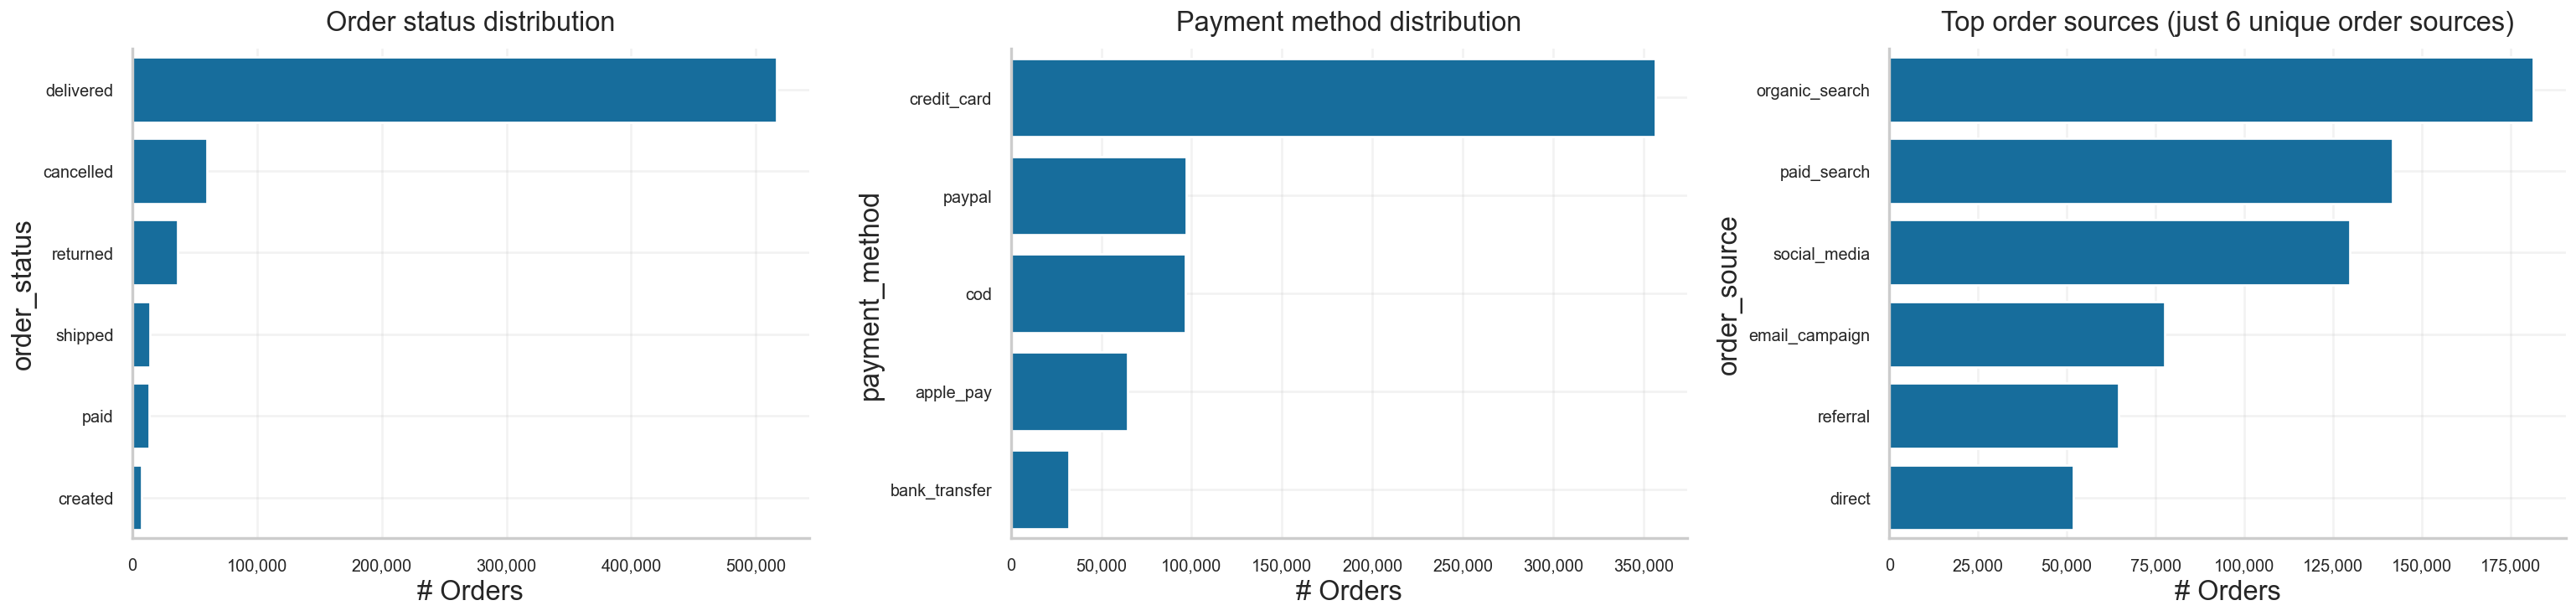

In [67]:
print_section("Univariate EDA — categorical distributions")

# -----------------------------
# Categorical: Orders overview
# -----------------------------
if orders_enriched is not None:
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    # Order status
    status_order = (
        orders_enriched["order_status"].value_counts(dropna=False).index.tolist()
        if "order_status" in orders_enriched.columns
        else []
    )
    if status_order:
        sns.countplot(data=orders_enriched, y="order_status", order=status_order, ax=axes[0])
        axes[0].set_title("Order status distribution")
        axes[0].set_xlabel("# Orders")
        axes[0].set_ylabel("order_status")

    # Payment method
    if "payment_method" in orders_enriched.columns:
        pay_order = orders_enriched["payment_method"].value_counts().index.tolist()
        sns.countplot(data=orders_enriched, y="payment_method", order=pay_order, ax=axes[1])
        axes[1].set_title("Payment method distribution")
        axes[1].set_xlabel("# Orders")
        axes[1].set_ylabel("payment_method")

    # Order source (top) (nunique = 6)
    if "order_source" in orders_enriched.columns:
        top_sources = orders_enriched["order_source"].value_counts().head(10).index.tolist()
        sns.countplot(data=orders_enriched, y="order_source", order=top_sources, ax=axes[2])
        axes[2].set_title("Top order sources (just 6 unique order sources)")
        axes[2].set_xlabel("# Orders")
        axes[2].set_ylabel("order_source")

    for ax in axes:
        format_axis_thousands(ax, axis="x")
        beautify_ax(ax)

    plt.tight_layout()
    plt.show()

#### 1. Observations (Data-level)
- `order_status` lệch mạnh về `delivered`; nhóm này áp đảo tuyệt đối so với các trạng thái còn lại.
- Trong các trạng thái không hoàn tất, `cancelled` cao hơn `returned`; `shipped`, `paid`, `created` rất nhỏ. Điều này cho thấy phần lớn order either đi tới hoàn tất hoặc rơi sớm khỏi funnel.
- `payment_method` tập trung mạnh vào `credit_card`; `paypal` và `cod` ở nhóm thứ hai và khá sát nhau; `apple_pay` thấp hơn rõ rệt; `bank_transfer` là nhỏ nhất.
- `order_source` tập trung ở `organic_search`, sau đó là `paid_search` và `social_media`. `email_campaign`, `referral`, `direct` nhỏ hơn đáng kể.
- Có imbalance rõ ở cả 3 biểu đồ: status tập trung vào `delivered`, payment tập trung vào `credit_card`, source tập trung vào search/social.
- Điểm cần lưu ý: `cancelled` lớn hơn `returned`, nên tổn thất có vẻ xảy ra nhiều hơn ở giai đoạn trước giao hàng hơn là sau giao hàng.

#### 2. Metric Interpretation
- `delivery_rate`: cao. Tỷ trọng `delivered` vượt xa phần còn lại, phản ánh hệ thống vẫn convert đơn đến completed state khá tốt.
- `return_rate`: thấp đến trung bình-thấp. `returned` có hiện diện nhưng nhỏ hơn nhiều so với `delivered`.
- `cancelled_rate`: không thấp tuyệt đối; đáng chú ý vì là trạng thái thất thoát lớn nhất sau `delivered`.
- Health hệ thống: nhìn chung khỏe ở đầu ra cuối funnel, nhưng vẫn có rò rỉ đáng kể ở bước hoàn tất đơn trước khi giao thành công.

#### 3. Business Insights
- Về vận hành: năng lực fulfillment có vẻ ổn vì `delivered` chiếm đa số lớn. Tuy nhiên `cancelled` cao hơn `returned` hàm ý bottleneck vận hành có khả năng nằm trước hoặc trong giai đoạn xử lý đơn hơn là chất lượng hậu giao.
- Về hành vi người dùng: khách hàng ưu tiên phương thức thanh toán quen thuộc và ít friction, đặc biệt là `credit_card`. Việc `cod` vẫn lớn cho thấy còn một tệp cần độ tin cậy cao trước khi trả tiền.
- Về acquisition: đơn hàng đang phụ thuộc mạnh vào `organic_search`, `paid_search`, `social_media`. Đây là các kênh chính nuôi funnel; `direct` nhỏ hơn cho thấy brand pull/returning intent chưa phải nguồn volume lớn.
- Liên hệ business goals:
  - `delivery`: đang là điểm mạnh tương đối.
  - `cancel`: là KPI nên ưu tiên vì đây là thất thoát lớn hơn return.
  - `return`: chưa phải red flag ở view tổng quan này, nhưng vẫn cần theo dõi theo source/payment/product.
  - `funnel`: volume đầu vào chủ yếu đến từ search/social, nên bất kỳ friction nào ở checkout/payment sẽ ảnh hưởng lớn toàn hệ thống.

#### 4. Funnel Implications
- `source`: funnel phụ thuộc vào search/social, nên nếu conversion hoặc cancellation kém ở các kênh này thì impact sẽ lớn nhất.
- `payment`: cơ cấu payment khá tập trung; nếu `credit_card` có friction thì ảnh hưởng rộng. Ngược lại, tối ưu checkout cho `credit_card` sẽ có leverage cao nhất.
- `order_status`: bottleneck chính hiện lên ở `cancelled`, không phải `returned`. Nghĩa là mất đơn xảy ra trước khi hoàn tất fulfillment hơn là do trải nghiệm sau mua.

#### 5. Actionable Recommendations
- High impact:
  - Phân rã `cancelled_rate` theo `payment_method` và `order_source` để xác định cụm thất thoát lớn nhất trong funnel.
  - Audit checkout flow của `credit_card` vì đây là phương thức chi phối volume; bất kỳ lỗi hay friction nhỏ nào cũng kéo KPI toàn hệ thống.
  - Ưu tiên đánh giá chất lượng traffic của `paid_search` và `social_media` qua conversion-to-delivery, không chỉ volume order.
- Medium:
  - So sánh `delivery_rate`, `cancelled_rate`, `return_rate` giữa `organic_search`, `paid_search`, `social_media` để tối ưu budget acquisition theo chất lượng đơn, không chỉ số lượng.
  - Kiểm tra nhóm `cod` riêng vì đây là payment có rủi ro vận hành/cancel thường đáng theo dõi trong e-commerce, dù biểu đồ này chưa đủ để kết luận.
- Low:
  - Theo dõi `bank_transfer` và `apple_pay` như các kênh thanh toán niche; chưa thấy dấu hiệu cần ưu tiên xử lý chỉ từ phân bố volume.
- Kết luận ưu tiên: chưa có dấu hiệu vấn đề lớn ở `delivery` hay `return` tại level tổng quan; vấn đề nổi bật nhất từ biểu đồ này là cần kiểm soát `cancelled` và đánh giá chất lượng funnel theo `source x payment_method`.

### EDA — numeric distributions

#### Overview

Mục tiêu: xem phân bố của các biến số quan trọng để hiểu xua hướng trung tâm, độ lệch và ngoại lệ.

Outline:
- Payment value
- Discount rate (clip p99)
- Gross profit (winsorized 1%-99%)


#### 1) Payment value distribution

Histogram + KDE cho `payment_value` trên `orders_enriched`.



Univariate EDA — numeric distributions


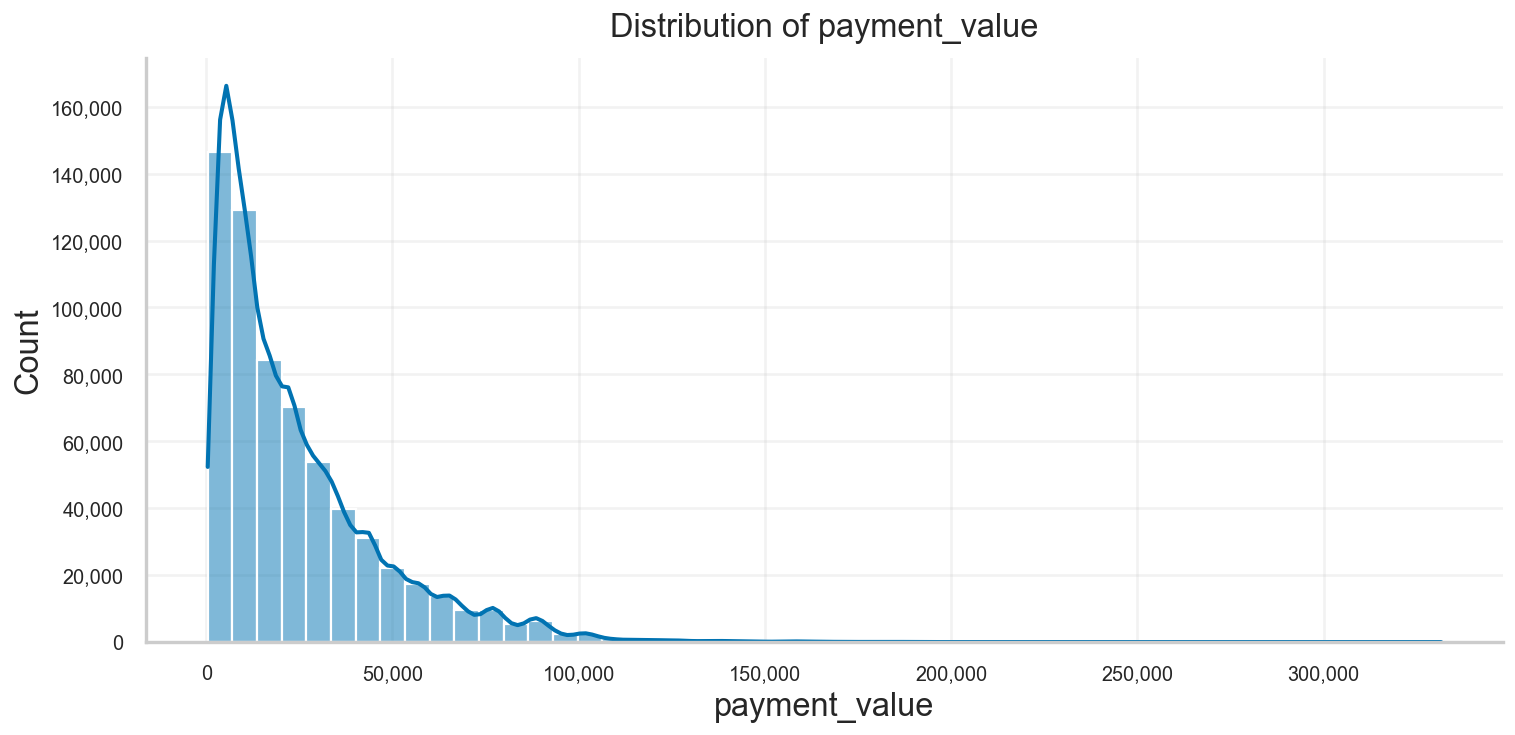

,metric,value
0,count,"646,945.00"
1,mean,"24,238.33"
2,median,"17,229.44"
3,p1,"3,873.71"
4,p75,"33,706.35"
5,p90,"55,476.30"
6,p95,"70,870.13"
7,p99,"98,075.75"
8,min,389.74
9,max,"331,570.40"


In [68]:
print_section("Univariate EDA — numeric distributions")

if orders_enriched is not None and "payment_value" in orders_enriched.columns:
    pv = orders_enriched["payment_value"].dropna()
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.histplot(pv, bins=50, kde=True, ax=ax)
    ax.set_title("Distribution of payment_value")
    ax.set_xlabel("payment_value")
    ax.set_ylabel("Count")
    format_axis_thousands(ax, axis="both")
    beautify_ax(ax)
    plt.tight_layout()
    plt.show()

    payment_value_summary = pd.DataFrame(
        {
            "metric": ["count", "mean", "median", "p1", "p75", "p90", "p95", "p99", "min", "max"],
            "value": [
                float(len(pv)),
                pv.mean(),
                pv.median(),
                pv.quantile(0.1),
                pv.quantile(0.75),
                pv.quantile(0.90),
                pv.quantile(0.95),
                pv.quantile(0.99),
                pv.min(),
                pv.max(),
            ],
        }
    )
    with pd.option_context("display.float_format", "{:,.2f}".format):
        display(payment_value_summary)


**`payment_value`**
- **Descriptive (What happened?)**: Biểu đồ cho thấy `payment_value` lệch phải rất mạnh; bảng summary xác nhận điều đó với `median = 17.2k`, `p75 = 33.7k`, `p90 = 55.5k`, `p99 = 98.1k`, trong khi `max = 331.6k`. Nghĩa là phần lớn đơn nằm ở vùng giá trị thấp-trung bình, còn một nhóm nhỏ kéo đuôi phải rất dài.
- **Diagnostic (Why did it happen?)**: Với grain `1 payment = 1 order` (quan hệ $1:1$), pattern này cho thấy basket nhỏ là mặt bằng chính của business; doanh thu nhiều khả năng phụ thuộc vào số lượng đơn hoàn tất hơn là vào số ít đơn rất lớn. `mean = 24.2k` cao hơn `median` cũng cho thấy AOV dễ bị tail kéo lên.
- **Predictive (What is likely to happen?)**: Nếu cấu trúc này giữ nguyên, tăng trưởng doanh thu sẽ tiếp tục phụ thuộc chủ yếu vào `traffic -> orders -> delivery`, không phải vào nhóm high-ticket orders hiếm. Đồng thời KPI như mean `payment_value` hoặc AOV sẽ biến động mạnh nếu tail thay đổi.
- **Prescriptive (What should we do?)**: Giữ riêng một cohort `top 5%-10% payment_value` để theo dõi `cancelled_rate` và `delivery_rate`, vì mất ít đơn ở tail cũng gây hụt doanh thu lớn. Trong dashboard điều hành, nên đặt `median`, `p90`, `p99` cạnh `mean` để đọc health funnel sát thực tế hơn.


#### 2) Discount rate distribution

Lọc giá trị hợp lệ (`>= 0`, không null) và clip đến $p99$ để dễ đọc hơn.


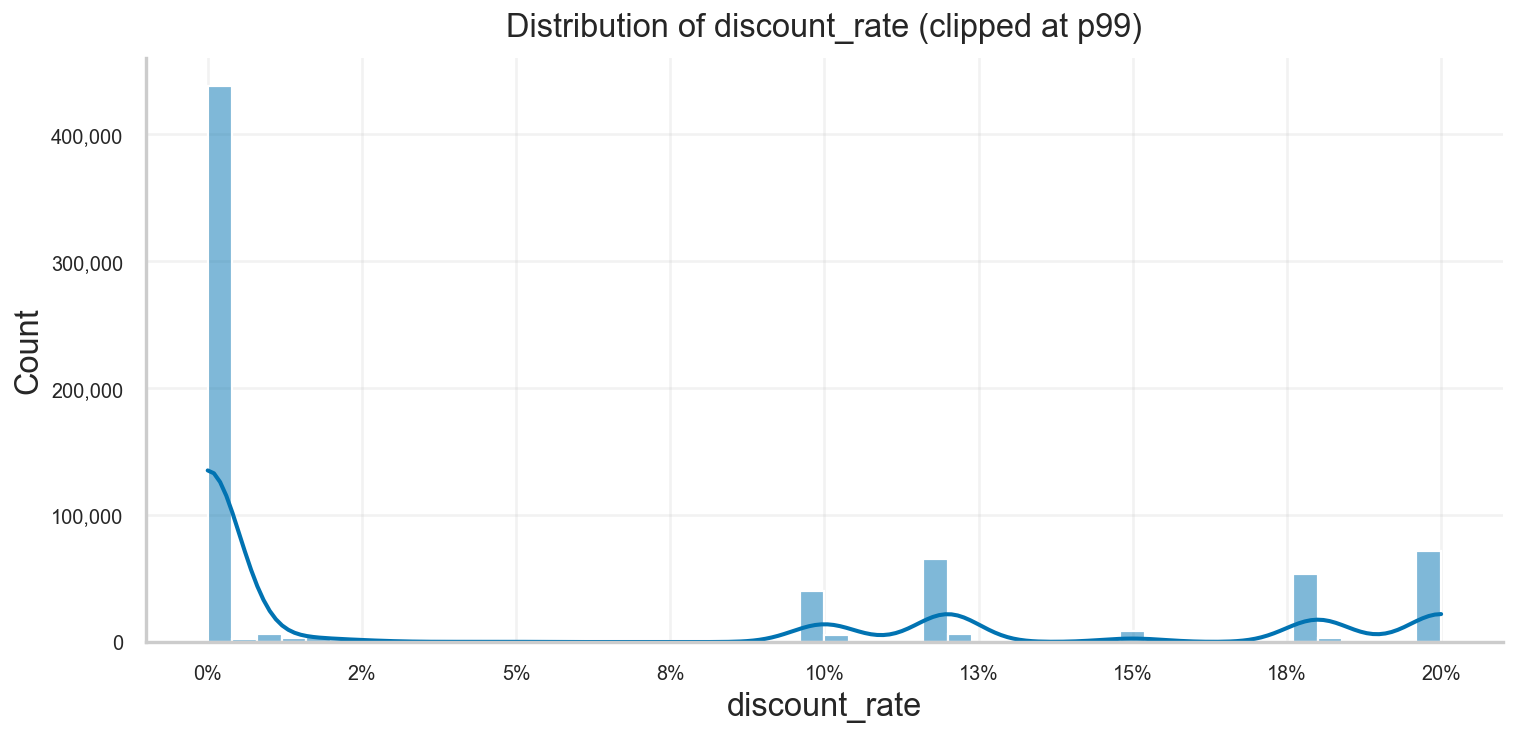

,metric,value
0,count,714669.0000
1,share_zero,0.6134
2,mean,0.0553
3,median,0.0000
4,p75,0.1200
5,p90,0.2000
6,p95,0.2000
7,p99,0.2000


,discount_rate,share
0,0.0000,0.6134
1,0.2000,0.1005
2,0.1200,0.1002
3,0.1800,0.0803
4,0.1000,0.0636
5,0.1500,0.0125
6,0.0090,0.0006
7,0.0092,0.0005


In [69]:
if line_items is not None and "discount_rate" in line_items.columns:
    # Clip extreme tails for readability
    dr = line_items["discount_rate"].copy()
    dr = dr[(dr.notna()) & (dr >= 0)]
    if len(dr):
        upper = dr.quantile(0.99)
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.histplot(dr.clip(upper=upper), bins=50, kde=True, ax=ax)
        ax.set_title("Distribution of discount_rate (clipped at p99)")
        ax.set_xlabel("discount_rate")
        ax.set_ylabel("Count")
        ax.xaxis.set_major_formatter(PCT_FMT_0)
        format_axis_thousands(ax, axis="y")
        beautify_ax(ax)
        plt.tight_layout()
        plt.show()

        discount_rate_summary = pd.DataFrame(
            {
                "metric": ["count", "share_zero", "mean", "median", "p75", "p90", "p95", "p99"],
                "value": [
                    float(len(dr)),
                    (dr == 0).mean(),
                    dr.mean(),
                    dr.median(),
                    dr.quantile(0.75),
                    dr.quantile(0.90),
                    dr.quantile(0.95),
                    dr.quantile(0.99),
                ],
            }
        )
        discount_rate_top_bands = (
            dr.round(4)
            .value_counts(normalize=True)
            .head(8)
            .rename_axis("discount_rate")
            .reset_index(name="share")
        )
        with pd.option_context("display.float_format", "{:.4f}".format):
            display(discount_rate_summary)
            display(discount_rate_top_bands)


**`discount_rate`**
- **Descriptive (What happened?)**: Biểu đồ và bảng summary cho thấy `discount_rate` dồn rất mạnh ở `0%`; `61.34%` line-item không có discount và `median = 0%`. Phần còn lại không phân bố liên tục mà tập trung vào vài band rõ rệt: `20%` (`10.05%` line-item), `12%` (`10.02%`), `18%` (`8.03%`), `10%` (`6.36%`), `15%` (`1.25%`). `p75 = 12%`, còn `p90-p99 = 20%`.
- **Diagnostic (Why did it happen?)**: Đây là pattern rất rõ của promotion theo rule cố định, không phải discount ngẫu nhiên. Vì phần lớn line-item vẫn bán ở `0%`, business hiện chưa phụ thuộc vào giảm giá diện rộng để tạo volume.
- **Predictive (What is likely to happen?)**: Nếu mix discount giữ nguyên, volume sẽ tiếp tục đến từ hai nhóm chính: non-discounted items và một số promo bands chuẩn hóa. Rủi ro KPI nằm ở việc tăng tỷ trọng band sâu như `18%-20%`, vì đây là vùng dễ bào mòn `gross_profit` nhanh hơn mức cải thiện funnel.
- **Prescriptive (What should we do?)**: Chuyển từ view “có discount hay không” sang view theo `discount band`, rồi đo riêng `delivered orders`, `cancelled_rate`, `return_rate`, `net_revenue`, `gross_profit`. Priority kiểm tra trước nên là các band `18%-20%` vì vừa có tỷ trọng đáng kể vừa là vùng discount sâu nhất trong phân phối hiện tại.


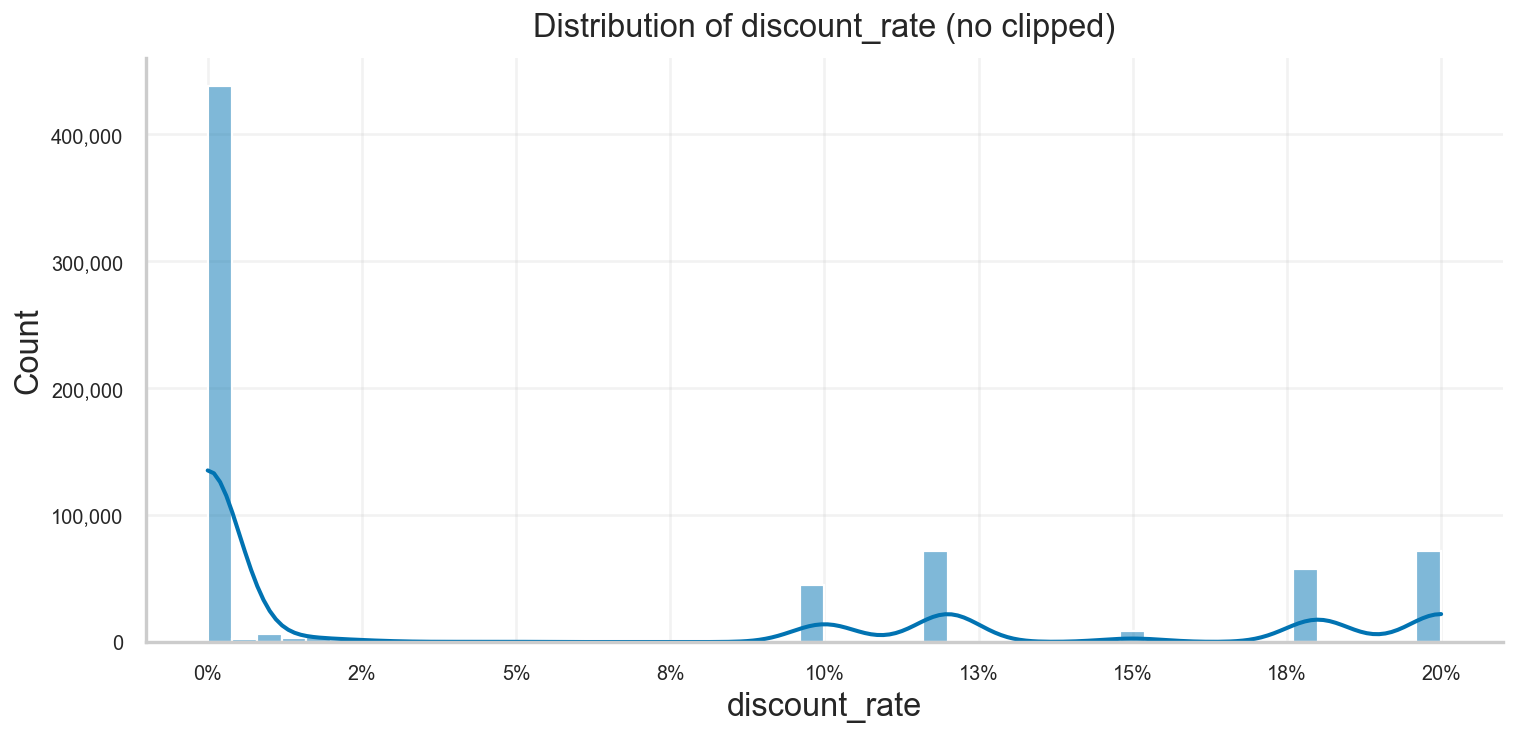

,metric,value
0,count,714669.0000
1,share_zero,0.6134
2,mean,0.0553
3,median,0.0000
4,p75,0.1200
5,p90,0.2000
6,p95,0.2000
7,p99,0.2000


,discount_rate,share
0,0.0000,0.6134
1,0.2000,0.1005
2,0.1200,0.1002
3,0.1800,0.0803
4,0.1000,0.0636
5,0.1500,0.0125
6,0.0090,0.0006
7,0.0092,0.0005


In [70]:
if line_items is not None and "discount_rate" in line_items.columns:
    # Clip extreme tails for readability
    dr = line_items["discount_rate"].copy()
    dr = dr[(dr.notna()) & (dr >= 0)]
    if len(dr):
        # upper = dr.quantile(1)
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.histplot(dr, bins=50, kde=True, ax=ax)
        ax.set_title("Distribution of discount_rate (no clipped)")
        ax.set_xlabel("discount_rate")
        ax.set_ylabel("Count")
        ax.xaxis.set_major_formatter(PCT_FMT_0)
        format_axis_thousands(ax, axis="y")
        beautify_ax(ax)
        plt.tight_layout()
        plt.show()

        discount_rate_summary = pd.DataFrame(
            {
                "metric": ["count", "share_zero", "mean", "median", "p75", "p90", "p95", "p99"],
                "value": [
                    float(len(dr)),
                    (dr == 0).mean(),
                    dr.mean(),
                    dr.median(),
                    dr.quantile(0.75),
                    dr.quantile(0.90),
                    dr.quantile(0.95),
                    dr.quantile(0.99),
                ],
            }
        )
        discount_rate_top_bands = (
            dr.round(4)
            .value_counts(normalize=True)
            .head(8)
            .rename_axis("discount_rate")
            .reset_index(name="share")
        )
        with pd.option_context("display.float_format", "{:.4f}".format):
            display(discount_rate_summary)
            display(discount_rate_top_bands)


#### 3) Gross profit distribution



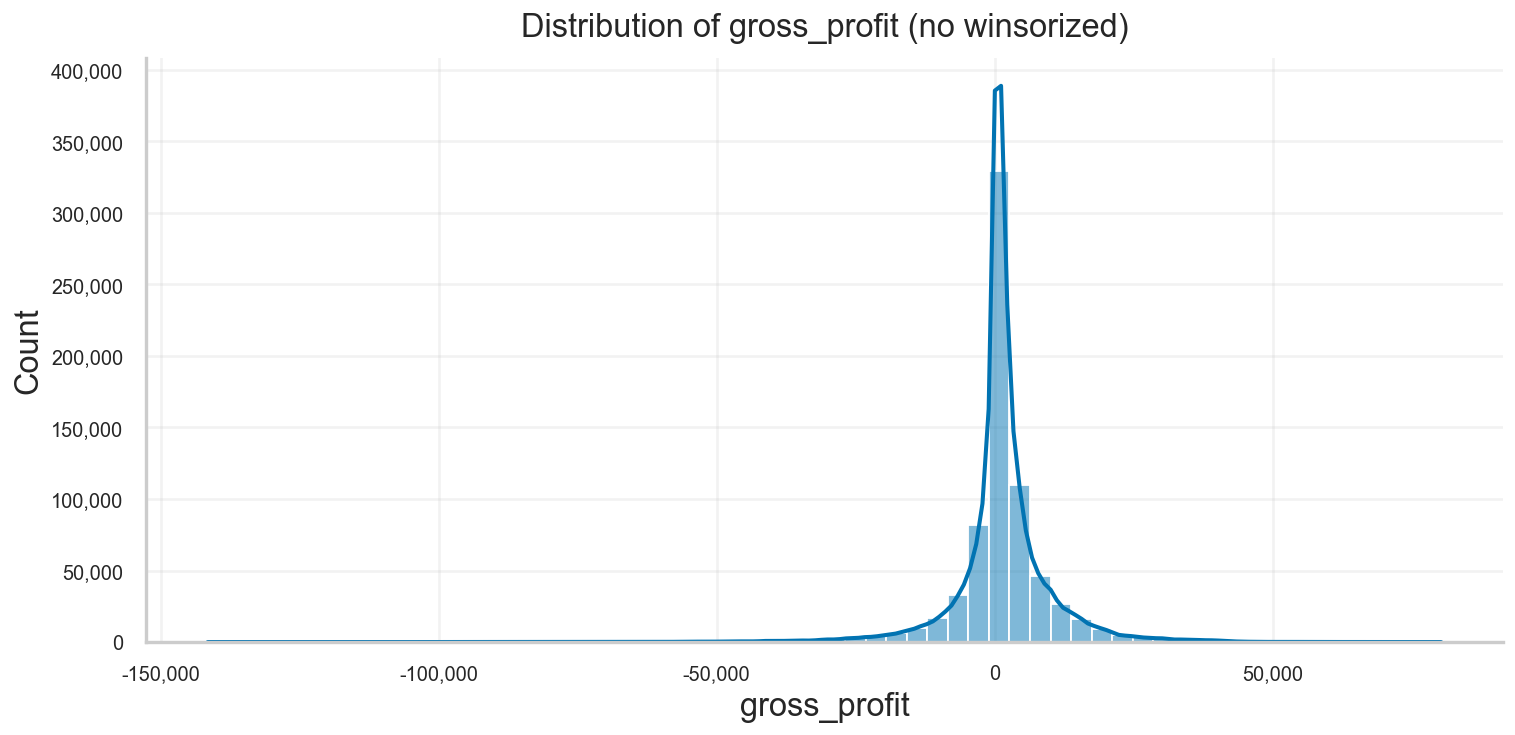

,metric,value
0,count,"714,669.0000"
1,mean,"1,408.7059"
2,median,946.1467
3,min,"-141,552.4160"
4,max,"80,311.6066"
5,p25,-662.7328
6,p75,"3,760.7416"
7,p90,"9,648.6522"
8,p95,"14,664.9263"
9,p99,"28,127.9920"


In [71]:
if line_items is not None and "gross_profit" in line_items.columns:
    gp = line_items["gross_profit"].copy().dropna()
    if len(gp):
        # lower, upper = gp.quantile([0.01, 0.99])
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.histplot(gp, bins=60, kde=True, ax=ax)
        ax.set_title("Distribution of gross_profit (no winsorized)")
        ax.set_xlabel("gross_profit")
        ax.set_ylabel("Count")
        format_axis_thousands(ax, axis="both")
        beautify_ax(ax)
        plt.tight_layout()
        plt.show()

        gross_profit_summary = pd.DataFrame(
            {
                "metric": [
                    "count",
                    "mean",
                    "median",
                    "min",
                    "max",
                    "p25",
                    "p75",
                    "p90",
                    "p95",
                    "p99",
                    "negative_share",
                    "positive_share",
                ],
                "value": [
                    float(len(gp)),
                    gp.mean(),
                    gp.median(),
                    gp.min(),
                    gp.max(),
                    gp.quantile(0.25),
                    gp.quantile(0.75),
                    gp.quantile(0.90),
                    gp.quantile(0.95),
                    gp.quantile(0.99),
                    (gp < 0).mean(),
                    (gp > 0).mean(),
                ],
            }
        )
        with pd.option_context("display.float_format", "{:,.4f}".format):
            display(gross_profit_summary)


Khoảng cách khổng lồ ở phần đuôi: Giá trị lớn nhất (max = 80,311) cao hơn gần gấp 3 lần so với bách phân vị thứ 99 (p99 = 28,579). Điều này có nghĩa là chỉ 1% dữ liệu trên cùng đã kéo dài một khoảng lên tới hơn 50,000 đơn vị. Tương tự ở chiều âm, min là -75,957 trong khi bách phân vị 1% (nhìn từ biểu đồ winsorized) chỉ nằm ở khoảng -20,000.

Mean vs Median lệch nhau: Giá trị trung bình (mean = 2,123) lớn gần gấp đôi trung vị (median = 1,116). Điều này cho thấy phân phối bị lệch phải (right-skewed) rất mạnh do bị kéo bởi các giá trị dương khổng lồ.

Biểu đồ "no winsorized": Đuôi dữ liệu (tails) kéo dãn quá dài ra hai bên khiến toàn bộ phần lớn dữ liệu (nằm quanh mức 0) bị ép lại thành một đường thẳng đứng hẹp. Điều này làm mất đi khả năng quan sát sự phân bổ thực sự của đại đa số dữ liệu.

##### Winsorize ở ngưỡng $1%-99%$ để giảm ảnh hướng ngoài lề.


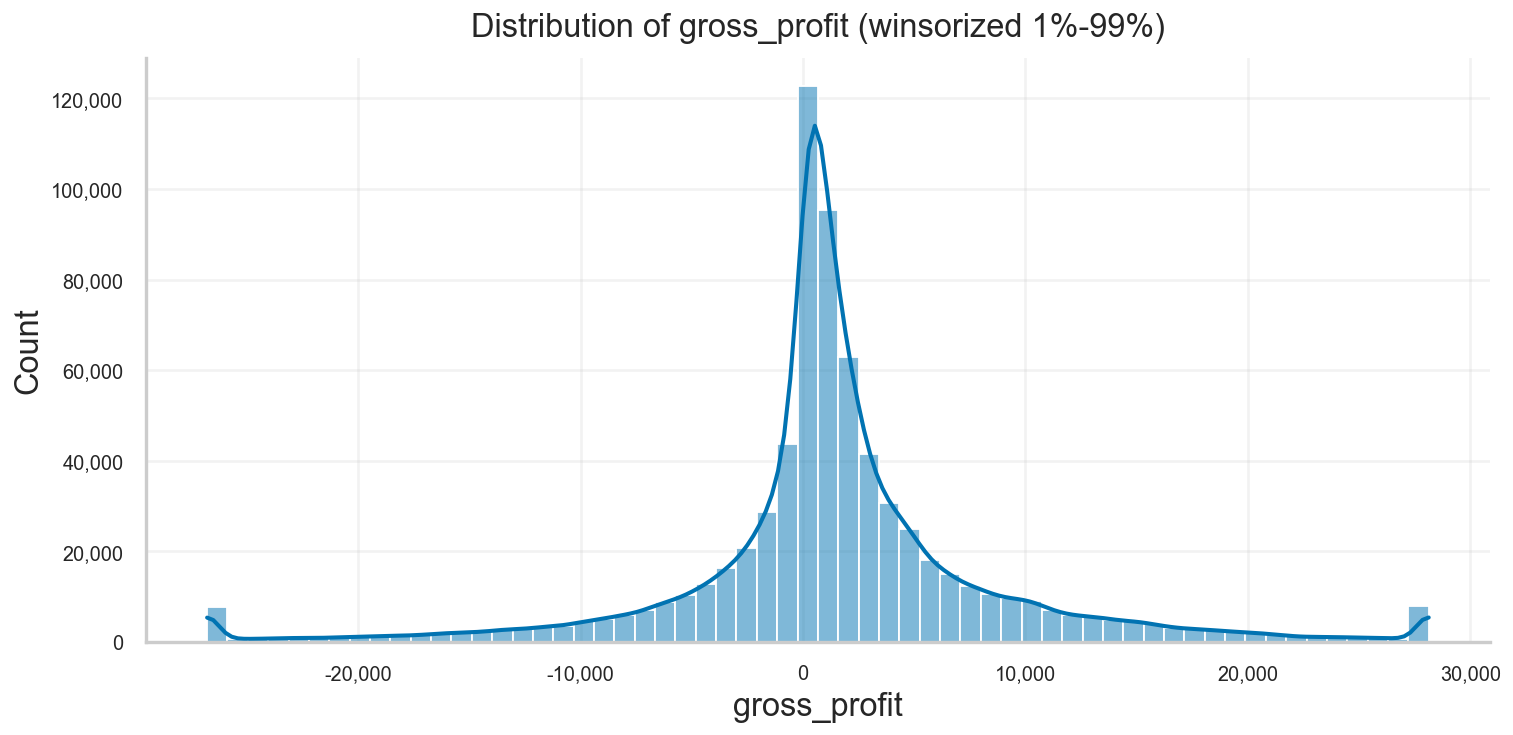

,metric,value
0,count,"714,669.0000"
1,mean,"1,408.7059"
2,median,946.1467
3,min,"-141,552.4160"
4,max,"80,311.6066"
5,p25,-662.7328
6,p75,"3,760.7416"
7,p90,"9,648.6522"
8,p95,"14,664.9263"
9,p99,"28,127.9920"


In [72]:
if line_items is not None and "gross_profit" in line_items.columns:
    gp = line_items["gross_profit"].copy().dropna()
    if len(gp):
        lower, upper = gp.quantile([0.01, 0.99])
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.histplot(gp.clip(lower=lower, upper=upper), bins=60, kde=True, ax=ax)
        ax.set_title("Distribution of gross_profit (winsorized 1%-99%)")
        ax.set_xlabel("gross_profit")
        ax.set_ylabel("Count")
        format_axis_thousands(ax, axis="both")
        beautify_ax(ax)
        plt.tight_layout()
        plt.show()

        gross_profit_summary = pd.DataFrame(
            {
                "metric": [
                    "count",
                    "mean",
                    "median",
                    "min",
                    "max",
                    "p25",
                    "p75",
                    "p90",
                    "p95",
                    "p99",
                    "negative_share",
                    "positive_share",
                ],
                "value": [
                    float(len(gp)),
                    gp.mean(),
                    gp.median(),
                    gp.min(),
                    gp.max(),
                    gp.quantile(0.25),
                    gp.quantile(0.75),
                    gp.quantile(0.90),
                    gp.quantile(0.95),
                    gp.quantile(0.99),
                    (gp < 0).mean(),
                    (gp > 0).mean(),
                ],
            }
        )
        with pd.option_context("display.float_format", "{:,.4f}".format):
            display(gross_profit_summary)



**`gross_profit`**
- **Descriptive (What happened?)**: Ngay cả sau winsorize `1%-99%`, `gross_profit` vẫn phân tán rộng và tập trung quanh vùng dương thấp. Bảng summary cho thấy `median = 1.1k`, `p25 = -173.9`, `p75 = 4.0k`, `p90 = 10.0k`, và `26.78%` line-item có profit âm trong khi `73.22%` là dương.
- **Diagnostic (Why did it happen?)**: Đây không còn là vấn đề của vài outlier cực đoan, vì sau khi cắt tail thì tỷ trọng âm vẫn lớn. Với công thức `gross_profit = net_revenue - cogs_total`, điều này cho thấy một phần đáng kể line-item đang bị ăn mòn unit economics bởi mix giá bán, COGS và/hoặc discount.
- **Predictive (What is likely to happen?)**: Nếu cơ cấu này giữ nguyên, business có thể vẫn cải thiện `delivery` hoặc order volume nhưng lợi nhuận sẽ không đi cùng nhịp. Nói cách khác, funnel có thể nhìn khỏe ở đầu ra giao hàng nhưng vẫn yếu ở lớp `delivered profit`.
- **Prescriptive (What should we do?)**: Ưu tiên bóc tách cohort `gross_profit < 0` theo `category`, `segment`, `discount band`, `payment_method`, `order_source`. Ở KPI điều hành, nên bổ sung `negative-profit share` và `gross_profit per delivered order` để tránh tối ưu volume nhưng làm xấu hiệu quả kinh tế của đơn hàng.


#### Actionable Recommendations
- **High impact**: Audit nhóm line-item có `gross_profit < 0` và gắn với band discount (`0%`, `10%`, `12%`, `18%`, `20%`) để xác định band nào đang gây lỗ nhiều nhất.
- **High impact**: Bổ sung dashboard theo `median payment_value`, `p90 payment_value`, `negative gross_profit share`; không dùng mean revenue/order làm chỉ báo duy nhất.
- **Medium impact**: So sánh `delivery_rate`, `cancelled_rate`, `return_rate` giữa nhóm có discount và không discount để xem promo có thực sự cải thiện funnel hay chỉ đổi margin lấy volume.
- **Medium impact**: Tách cohort high-value orders (`top 10% payment_value`) để theo dõi riêng thất thoát funnel; mất đơn ở nhóm này tác động doanh thu lớn hơn mặt bằng chung.
- **Low impact**: Nếu chưa thấy vấn đề lớn ở `payment_value` distribution, chưa cần can thiệp pricing diện rộng; ưu tiên xử lý unit economics ở `gross_profit` trước.

### EDA — returns


Univariate EDA — returns


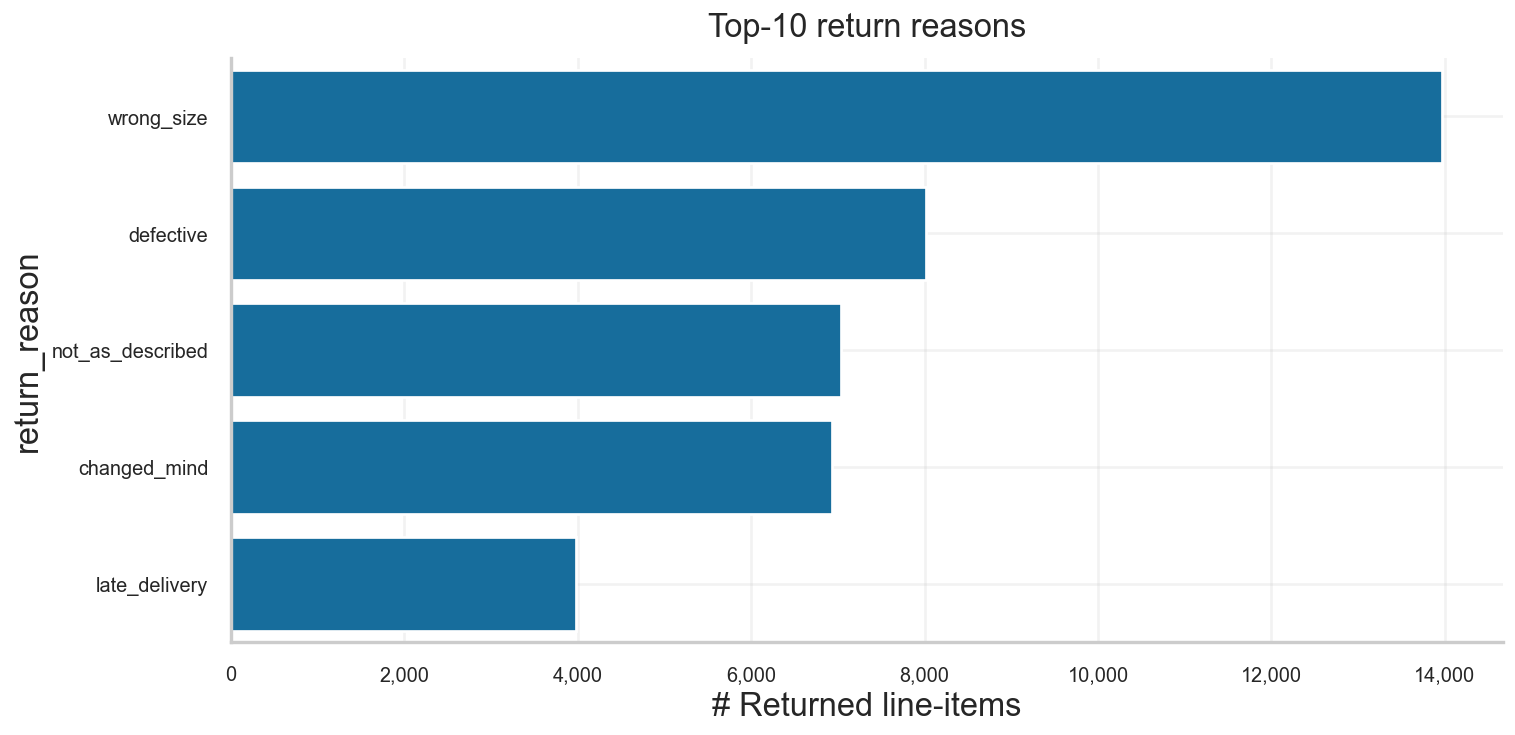

In [73]:
print_section("Univariate EDA — returns")

if returns_enriched is not None and "return_reason" in returns_enriched.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    reason_order = returns_enriched["return_reason"].value_counts().head(10).index.tolist()
    sns.countplot(data=returns_enriched, y="return_reason", order=reason_order, ax=ax)
    ax.set_title("Top-10 return reasons")
    ax.set_xlabel("# Returned line-items")
    ax.set_ylabel("return_reason")
    format_axis_thousands(ax, axis="x")
    beautify_ax(ax)
    plt.tight_layout()
    plt.show()

### Template ghi insight (copy/paste sau mỗi chart)
- **Descriptive (What happened?)**: 
- **Diagnostic (Why did it happen?)**: 
- **Predictive (What is likely to happen?)**: 
- **Prescriptive (What should we do?)**: 

> Mục tiêu: mỗi insight đều có “ý nghĩa kinh doanh” + hành động đề xuất (kèm ước lượng/định lượng nếu có).

## 4. EDA — Bivariate (2 biến)

### Quy tắc
- **Số – Số**: tính tương quan (Pearson/Spearman) **trước** rồi mới chọn biểu đồ (scatter/hexbin/regplot).
- **Số – Phân loại**: dùng **cross table / pivot** + boxplot/violin để so sánh phân phối.
- **Phân loại – Phân loại**: dùng **Chi-square** và đo độ mạnh liên hệ bằng **Cramer's V**; trực quan hoá bằng heatmap/stacked bar.

> Lưu ý: correlation không đồng nghĩa với nhân quả — dùng phần “Diagnostic” để đặt giả thuyết và kiểm chứng thêm.


Bivariate EDA — numeric ↔ numeric (correlation)


,quantity,unit_price,discount_amount,discount_rate,list_price,net_revenue,gross_profit,gross_margin,shipping_fee,shipping_lead_time_days,payment_value,installments
quantity,1.00,-0.00,0.23,-0.00,0.52,0.51,0.09,-0.00,-0.36,0.00,0.50,0.00
unit_price,-0.00,1.00,0.22,-0.17,0.76,0.74,0.19,-0.09,-0.34,0.00,0.71,0.01
discount_amount,0.23,0.22,1.00,0.61,0.33,0.23,-0.38,-0.03,-0.14,-0.00,0.21,0.00
discount_rate,-0.00,-0.17,0.61,1.00,-0.13,-0.19,-0.34,0.01,0.09,-0.00,-0.20,-0.00
list_price,0.52,0.76,0.33,-0.13,1.00,0.97,0.23,-0.07,-0.34,0.00,0.95,0.00
net_revenue,0.51,0.74,0.23,-0.19,0.97,1.00,0.38,-0.07,-0.33,0.00,0.93,0.01
gross_profit,0.09,0.19,-0.38,-0.34,0.23,0.38,1.00,0.41,-0.06,0.00,0.27,0.01
gross_margin,-0.00,-0.09,-0.03,0.01,-0.07,-0.07,0.41,1.00,0.03,0.00,-0.06,0.00
shipping_fee,-0.36,-0.34,-0.14,0.09,-0.34,-0.33,-0.06,0.03,1.00,-0.00,-0.36,-0.01
shipping_lead_time_days,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,1.00,0.00,0.00


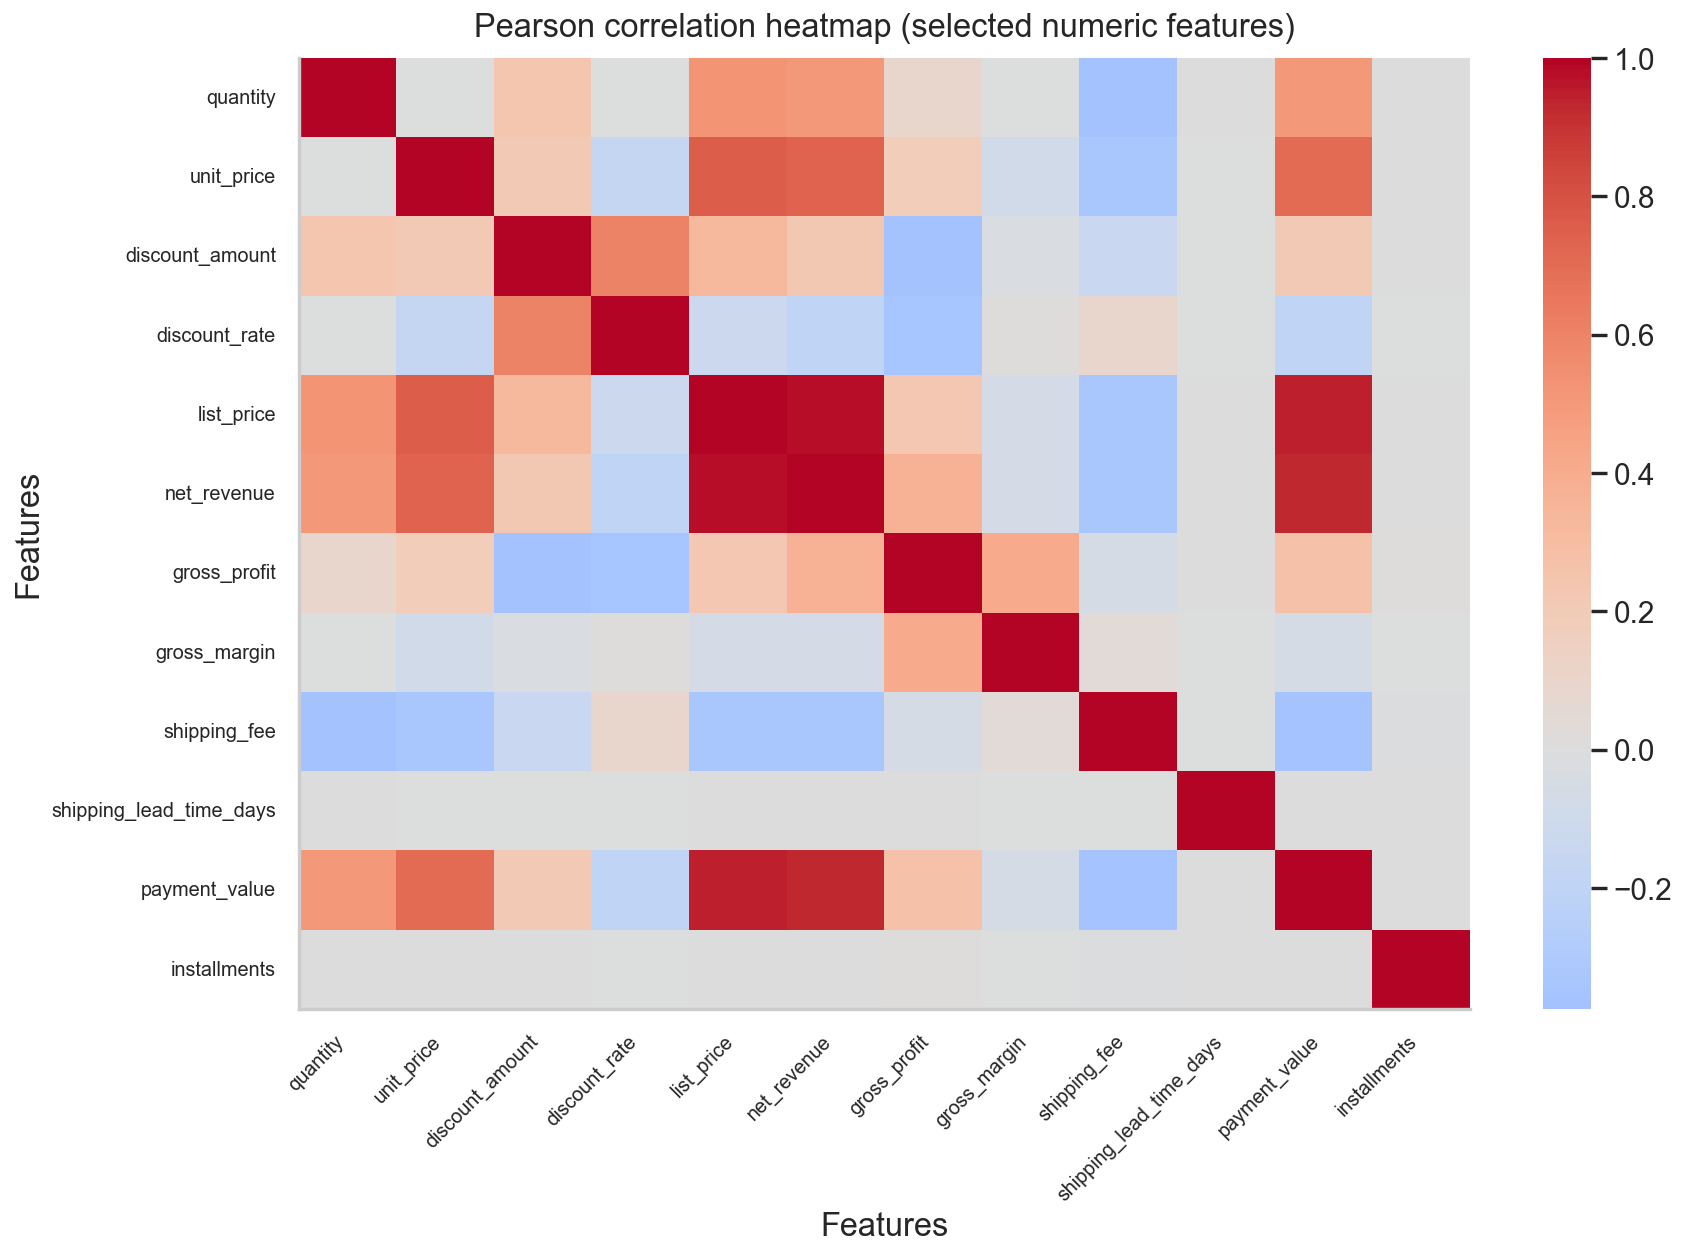

net_revenue    list_price      0.97
list_price     net_revenue     0.97
payment_value  list_price      0.95
list_price     payment_value   0.95
net_revenue    payment_value   0.93
payment_value  net_revenue     0.93
list_price     unit_price      0.76
unit_price     list_price      0.76
net_revenue    unit_price      0.74
unit_price     net_revenue     0.74
Name: abs_corr, dtype: float64


Bivariate EDA — numeric ↔ numeric (example plot)


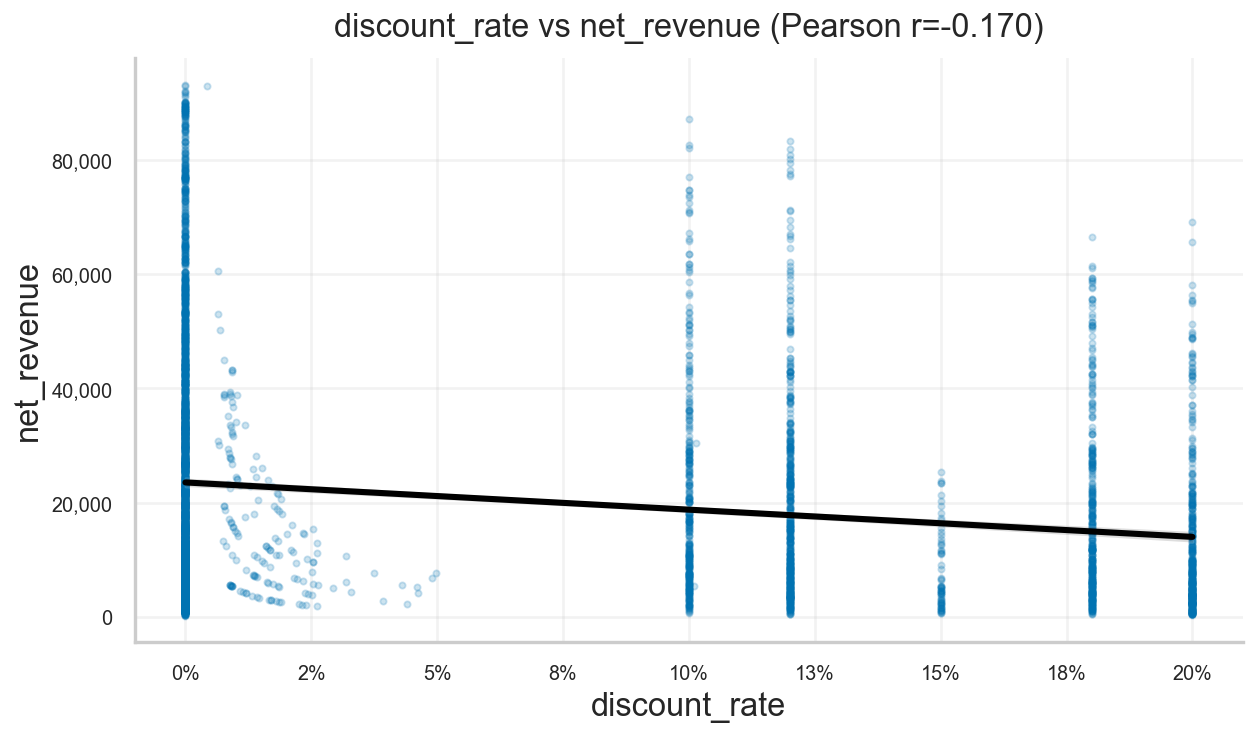


Bivariate EDA — numeric ↔ categorical (pivot/crosstab)


,n,mean,median
order_source,,,
direct,57329,21334.37,13837.20
paid_search,156500,21285.48,13781.56
referral,71256,21260.07,13608.39
social_media,143306,21218.71,13624.97
email_campaign,85849,21191.52,13703.71
organic_search,200429,21159.65,13687.80


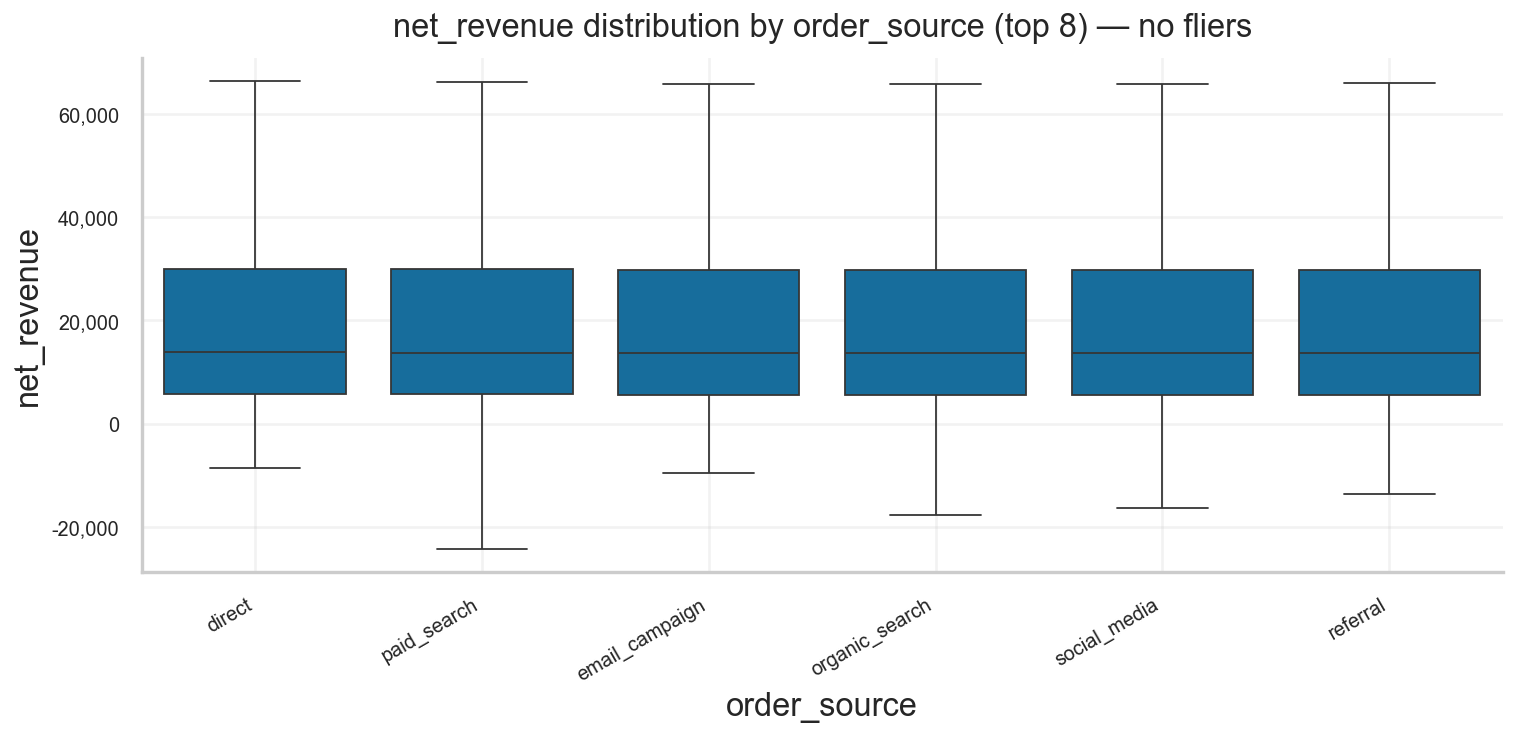


Bivariate EDA — categorical ↔ categorical (Chi-square / Cramer's V)
Chi-square test: chi2=9478.42, dof=20, p-value=0
Cramer's V (strength): 0.060


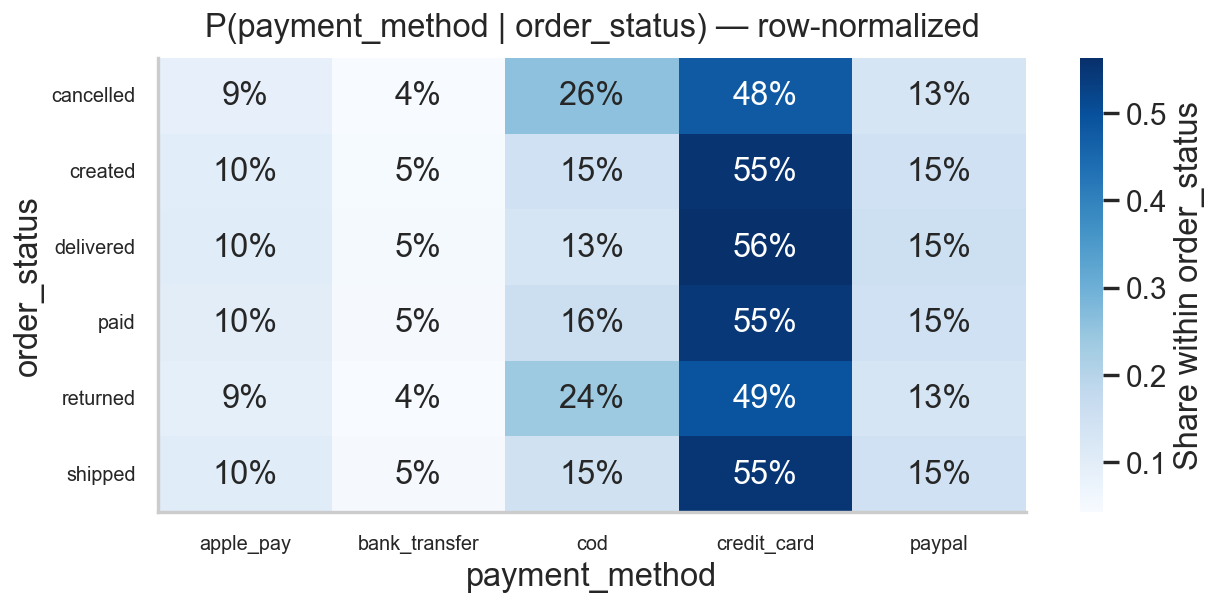

In [74]:
print_section("Bivariate EDA — numeric ↔ numeric (correlation)")

if line_items is not None:
    candidate_numeric = [
        "quantity",
        "unit_price",
        "discount_amount",
        "discount_rate",
        "list_price",
        "net_revenue",
        "gross_profit",
        "gross_margin",
        "shipping_fee",
        "shipping_lead_time_days",
        "payment_value",
        "installments",
    ]

    numeric_cols = [c for c in candidate_numeric if c in line_items.columns]

    if len(numeric_cols) >= 3:
        corr_pearson = line_items[numeric_cols].corr(method="pearson")
        display(corr_pearson.round(3))

        fig, ax = plt.subplots(figsize=(14, 10))
        sns.heatmap(corr_pearson, annot=False, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("Pearson correlation heatmap (selected numeric features)")
        ax.set_xlabel("Features")
        ax.set_ylabel("Features")
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        plt.setp(ax.get_yticklabels(), rotation=0)
        ax.tick_params(axis="both", labelsize=11)
        sns.despine(ax=ax, left=False, bottom=False)
        plt.tight_layout()
        plt.show()

        # Show strongest absolute correlations (excluding self-correlation)
        corr_long = (
            corr_pearson.abs()
            .where(~np.eye(len(corr_pearson), dtype=bool))
            .stack()
            .sort_values(ascending=False)
        )
        display(corr_long.head(10).rename("abs_corr"))

print_section("Bivariate EDA — numeric ↔ numeric (example plot)")

# Example: discount_rate vs net_revenue
if line_items is not None and {"discount_rate", "net_revenue"}.issubset(line_items.columns):
    tmp = line_items[["discount_rate", "net_revenue"]].dropna().copy()
    if len(tmp):
        # Trim extreme tails for readability
        tmp = tmp[tmp["discount_rate"].between(0, tmp["discount_rate"].quantile(0.99))]
        tmp = tmp[tmp["net_revenue"].between(tmp["net_revenue"].quantile(0.01), tmp["net_revenue"].quantile(0.99))]

        r = tmp["discount_rate"].corr(tmp["net_revenue"], method="pearson")
        sample_df = tmp.sample(min(len(tmp), 5000), random_state=42)

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.regplot(
            data=sample_df,
            x="discount_rate",
            y="net_revenue",
            scatter_kws={"alpha": 0.2, "s": 12},
            line_kws={"color": "black"},
            ax=ax,
        )
        ax.set_title(f"discount_rate vs net_revenue (Pearson r={r:.3f})")
        ax.set_xlabel("discount_rate")
        ax.set_ylabel("net_revenue")
        ax.xaxis.set_major_formatter(PCT_FMT_0)
        format_axis_thousands(ax, axis="y")
        beautify_ax(ax)
        plt.tight_layout()
        plt.show()

print_section("Bivariate EDA — numeric ↔ categorical (pivot/crosstab)")

# Numeric-Categorical: net_revenue by order_source (top 8)
if line_items is not None and {"order_source", "net_revenue"}.issubset(line_items.columns):
    top_sources = line_items["order_source"].value_counts().head(8).index
    tmp = line_items[line_items["order_source"].isin(top_sources)][["order_source", "net_revenue"]].dropna()

    # Pivot summary
    pivot = (
        tmp.groupby("order_source")
        .agg(n=("net_revenue", "size"), mean=("net_revenue", "mean"), median=("net_revenue", "median"))
        .sort_values("mean", ascending=False)
    )
    display(pivot)

    order = pivot.sort_values("median", ascending=False).index.tolist()

    # Boxplot (distribution)
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=tmp, x="order_source", y="net_revenue", order=order, showfliers=False, ax=ax)
    ax.set_title("net_revenue distribution by order_source (top 8) — no fliers")
    ax.set_xlabel("order_source")
    ax.set_ylabel("net_revenue")
    format_axis_thousands(ax, axis="y")
    plt.xticks(rotation=30, ha="right")
    beautify_ax(ax)
    plt.tight_layout()
    plt.show()

print_section("Bivariate EDA — categorical ↔ categorical (Chi-square / Cramer's V)")


def cramers_v(confusion: pd.DataFrame) -> float:
    """Cramer's V association for categorical-categorical."""
    if stats is None:
        return float("nan")

    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.to_numpy().sum()
    if n == 0:
        return float("nan")

    r, k = confusion.shape
    phi2 = chi2 / n

    # Bias correction (optional but usually better for many categories)
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    return float(np.sqrt(phi2corr / denom)) if denom > 0 else float("nan")


if orders_enriched is not None and {"order_status", "payment_method"}.issubset(orders_enriched.columns):
    confusion = pd.crosstab(orders_enriched["order_status"], orders_enriched["payment_method"], dropna=False)

    if stats is not None:
        chi2, p, dof, _ = stats.chi2_contingency(confusion)
        v = cramers_v(confusion)
        print(f"Chi-square test: chi2={chi2:.2f}, dof={dof}, p-value={p:.3g}")
        print(f"Cramer's V (strength): {v:.3f}")
    else:
        print("SciPy not available → skipping Chi-square/Cramer's V.")

    # Visualize row-normalized distribution
    confusion_norm = confusion.div(confusion.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        confusion_norm,
        cmap="Blues",
        annot=True,
        fmt=".0%",
        cbar_kws={"label": "Share within order_status"},
        ax=ax,
    )
    ax.set_title("P(payment_method | order_status) — row-normalized")
    ax.set_xlabel("payment_method")
    ax.set_ylabel("order_status")
    plt.setp(ax.get_xticklabels(), rotation=0)
    plt.setp(ax.get_yticklabels(), rotation=0)
    ax.tick_params(axis="both", labelsize=11)
    sns.despine(ax=ax, left=False, bottom=False)
    plt.tight_layout()
    plt.show()

## 4.5 Multivariate Funnel Diagnostics

Mục tiêu: triển khai trực tiếp các recommendation về `cancelled_rate`, chất lượng kênh `order_source`, và rủi ro theo `payment_method` ở mức đa biến (`source x payment x status`).

In [75]:
print_section("Multivariate EDA — funnel diagnostics (source × payment × status)")


def display_4dp(df: pd.DataFrame):
    """Display dataframe with float columns shown at 4 decimals (no jinja2 needed)."""
    out = df.copy()
    float_cols = out.select_dtypes(include=["floating"]).columns
    if len(float_cols):
        with pd.option_context("display.float_format", "{:.4f}".format):
            display(out)
    else:
        display(out)


required_cols = {"order_id", "order_status", "payment_method", "order_source", "order_date"}
if orders_enriched is None or not required_cols.issubset(orders_enriched.columns):
    print("Missing required columns in orders_enriched for multivariate diagnostics.")
else:
    fig_dir = OUTPUT_DIR / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)

    top_sources = orders_enriched["order_source"].value_counts().head(6).index.tolist()
    print(f"Top sources in scope: {top_sources}")






Multivariate EDA — funnel diagnostics (source × payment × status)
Top sources in scope: ['organic_search', 'paid_search', 'social_media', 'email_campaign', 'referral', 'direct']


,order_source,orders,delivery_rate,cancelled_rate,return_rate
2,organic_search,181495,0.7982,0.0923,0.0560
3,paid_search,141652,0.7988,0.0910,0.0558
5,social_media,129710,0.8000,0.0913,0.0554
1,email_campaign,77572,0.7986,0.0919,0.0564
4,referral,64565,0.7990,0.0934,0.0556
0,direct,51951,0.7967,0.0928,0.0560


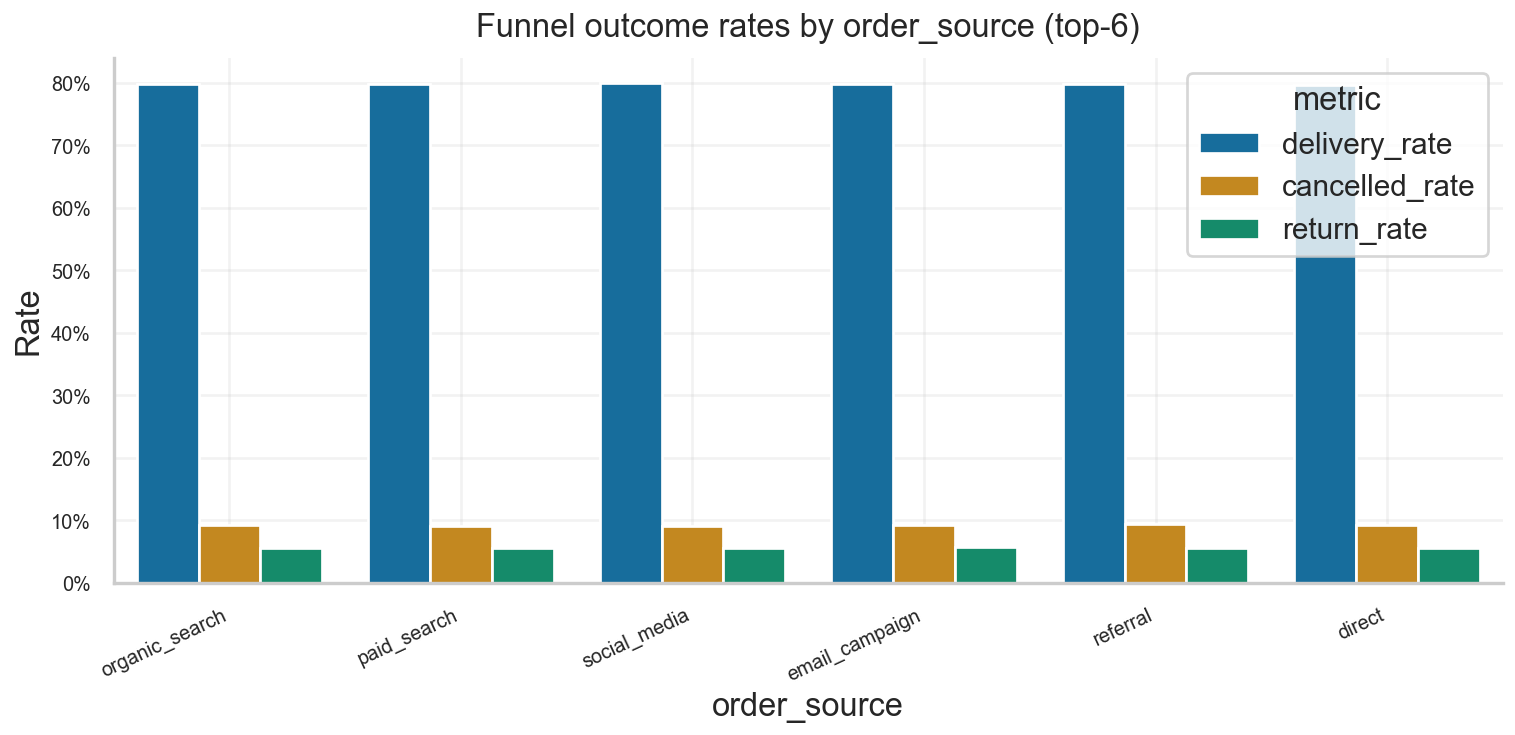

In [76]:
# 1) Outcome rates theo order_source
if orders_enriched is not None and "top_sources" in globals():
    status_src = (
        orders_enriched[orders_enriched["order_source"].isin(top_sources)]
        .assign(
            delivered_flag=lambda d: (d["order_status"] == "delivered").astype(int),
            cancelled_flag=lambda d: (d["order_status"] == "cancelled").astype(int),
            returned_flag=lambda d: (d["order_status"] == "returned").astype(int),
        )
        .groupby("order_source", as_index=False)
        .agg(
            orders=("order_id", "nunique"),
            delivery_rate=("delivered_flag", "mean"),
            cancelled_rate=("cancelled_flag", "mean"),
            return_rate=("returned_flag", "mean"),
        )
        .sort_values("orders", ascending=False)
    )
    display_4dp(status_src)

    rates_long = status_src.melt(
        id_vars=["order_source", "orders"],
        value_vars=["delivery_rate", "cancelled_rate", "return_rate"],
        var_name="metric",
        value_name="rate",
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=rates_long, x="order_source", y="rate", hue="metric", ax=ax)
    ax.set_title("Funnel outcome rates by order_source (top-6)")
    ax.set_xlabel("order_source")
    ax.set_ylabel("Rate")
    ax.yaxis.set_major_formatter(PCT_FMT_0)
    plt.xticks(rotation=25, ha="right")
    beautify_ax(ax)
    plt.tight_layout()
    plt.savefig(fig_dir / "multivar_source_outcome_rates.png", dpi=160, bbox_inches="tight")
    plt.show()



### Insight
- `delivery_rate` gần như đồng đều giữa 6 source lớn, dao động hẹp quanh `79.7%–80.0%`. Chênh lệch giữa source tốt nhất và thấp nhất rất nhỏ, nên chưa có dấu hiệu bottleneck lớn ở tầng source-level.
- `cancelled_rate` cũng khá sát nhau (`~9.1%–9.3%`), cho thấy thất thoát trước giao hàng là vấn đề mang tính hệ thống hơn là do riêng một acquisition channel.
- `return_rate` ổn định quanh `~5.5%–5.6%`, thấp hơn rõ so với `cancelled_rate`. Điều này nhất quán với [ORDER.md](/Users/tawannt/Study/Competition/Datathon/VinUni/ORDER.md): leak chính của funnel nằm trước delivery hơn là sau delivery.
- Hàm ý business: tối ưu budget theo source chỉ dựa trên volume là chưa đủ; về chất lượng funnel cuối, top source đang khá tương đồng nhau.


payment_method,apple_pay,bank_transfer,cod,credit_card,paypal
order_source,,,,,
direct,0.0804,0.0869,0.1604,0.0793,0.0850
email_campaign,0.0777,0.0777,0.1644,0.0790,0.0811
organic_search,0.0791,0.0773,0.1612,0.0802,0.0824
paid_search,0.0797,0.0747,0.1592,0.0791,0.0796
referral,0.0853,0.0852,0.1625,0.0812,0.0778
social_media,0.0809,0.0802,0.1551,0.0802,0.0784


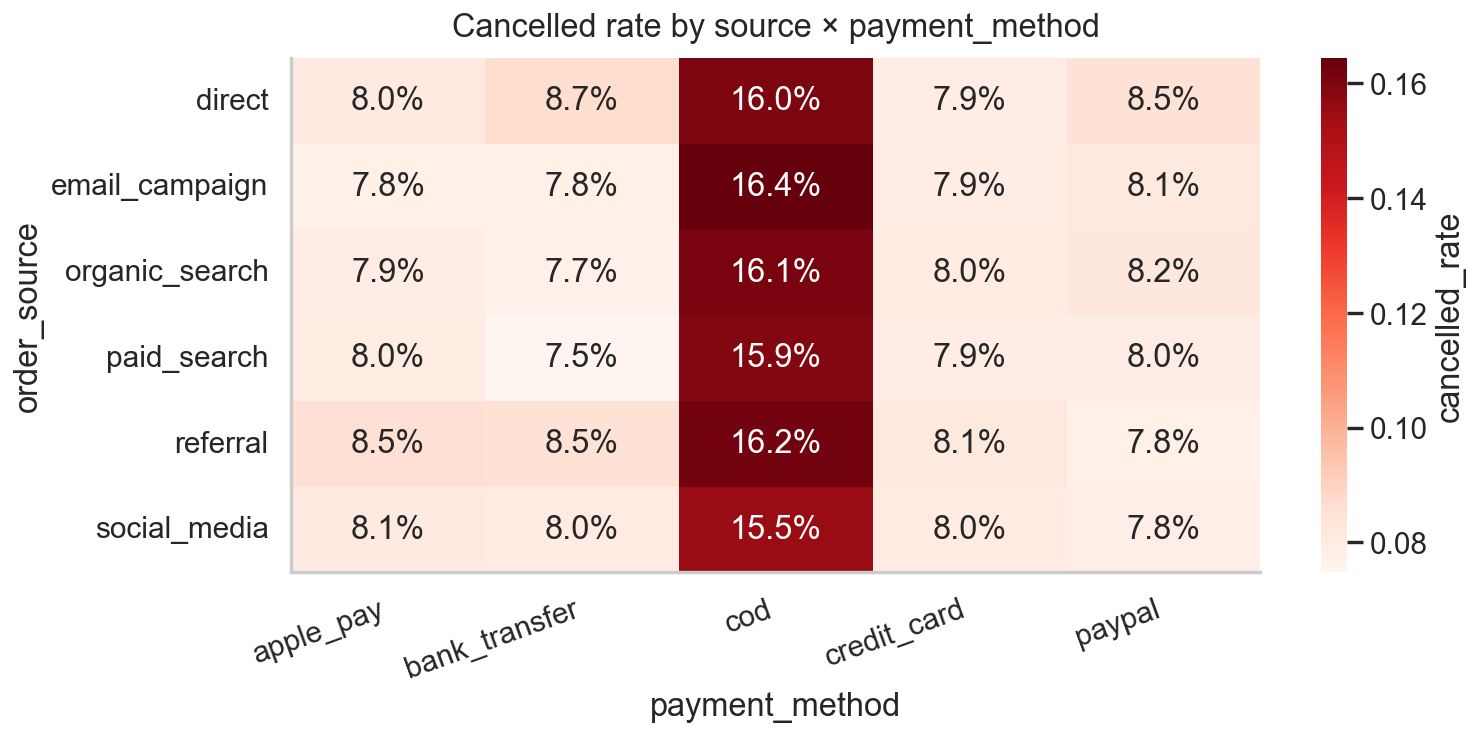

In [77]:
# 2) Heatmap cancelled_rate theo source × payment_method
if orders_enriched is not None and "top_sources" in globals():
    cube = orders_enriched[orders_enriched["order_source"].isin(top_sources)].copy()
    cube["cancelled_flag"] = (cube["order_status"] == "cancelled").astype(int)

    cancel_pivot = pd.pivot_table(
        cube,
        index="order_source",
        columns="payment_method",
        values="cancelled_flag",
        aggfunc="mean",
    ).fillna(0)
    display_4dp(cancel_pivot)

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(cancel_pivot, cmap="Reds", annot=True, fmt=".1%", cbar_kws={"label": "cancelled_rate"}, ax=ax)
    ax.set_title("Cancelled rate by source × payment_method")
    ax.set_xlabel("payment_method")
    ax.set_ylabel("order_source")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    plt.setp(ax.get_yticklabels(), rotation=0)
    sns.despine(ax=ax, left=False, bottom=False)
    plt.tight_layout()
    plt.savefig(fig_dir / "multivar_cancel_rate_source_payment.png", dpi=160, bbox_inches="tight")
    plt.show()



### Insight
- Tín hiệu mạnh nhất nằm ở `payment_method`, không nằm ở `order_source`: với mọi source, `cod` đều có `cancelled_rate` cao nhất, khoảng `15.5%–16.4%`, gần gấp đôi các phương thức còn lại (`~7.5%–8.7%`).
- Theo chiều source, khác biệt nhỏ hơn nhiều so với theo chiều payment. Nghĩa là rủi ro cancel đang được giải thích bởi phương thức thanh toán nhiều hơn bởi kênh acquisition.
- Hàm ý KPI: nếu mục tiêu là giảm `cancelled_rate`, đòn bẩy lớn nhất là kiểm soát funnel của `cod`, không phải dàn trải tối ưu trên từng source.
- Priority: nên theo dõi `source x cod` như một cluster rủi ro, nhưng không nên kết luận source nào “xấu” nếu chưa có thêm volume mix và kiểm định sâu hơn.
- COD có cancel_rate cao thì có phải


,payment_group,orders,delivery_rate,cancelled_rate,return_rate
0,credit_card,356352,0.8168,0.0798,0.0500
1,other_methods,290593,0.7765,0.1067,0.0631


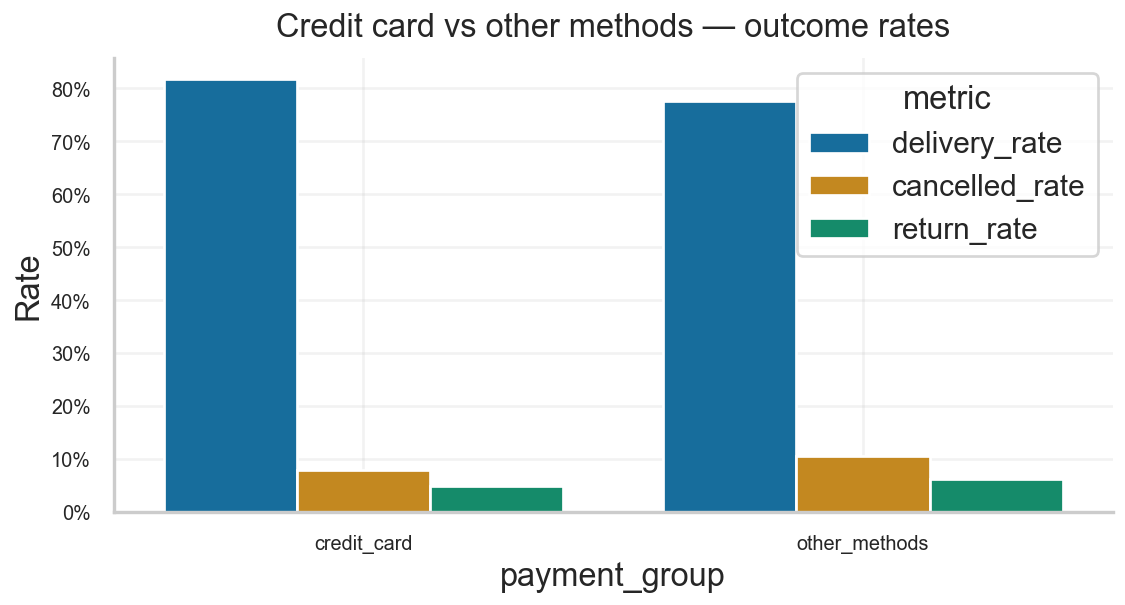

In [78]:
# 3) Credit card checkout audit proxy: credit_card vs other_methods
if orders_enriched is not None:
    cc = orders_enriched.copy()
    cc["payment_group"] = np.where(cc["payment_method"] == "credit_card", "credit_card", "other_methods")

    cc_mix = (
        cc.assign(
            delivered_flag=(cc["order_status"] == "delivered").astype(int),
            cancelled_flag=(cc["order_status"] == "cancelled").astype(int),
            returned_flag=(cc["order_status"] == "returned").astype(int),
        )
        .groupby("payment_group", as_index=False)
        .agg(
            orders=("order_id", "nunique"),
            delivery_rate=("delivered_flag", "mean"),
            cancelled_rate=("cancelled_flag", "mean"),
            return_rate=("returned_flag", "mean"),
        )
    )
    display_4dp(cc_mix)

    cc_long = cc_mix.melt(
        id_vars=["payment_group", "orders"],
        value_vars=["delivery_rate", "cancelled_rate", "return_rate"],
        var_name="metric",
        value_name="rate",
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=cc_long, x="payment_group", y="rate", hue="metric", ax=ax)
    ax.set_title("Credit card vs other methods — outcome rates")
    ax.set_xlabel("payment_group")
    ax.set_ylabel("Rate")
    ax.yaxis.set_major_formatter(PCT_FMT_0)
    beautify_ax(ax)
    plt.tight_layout()
    plt.savefig(fig_dir / "multivar_creditcard_vs_other_outcomes.png", dpi=160, bbox_inches="tight")
    plt.show()



### Insight
- Nhóm `credit_card` cho chất lượng funnel tốt hơn rõ: `delivery_rate = 81.68%` so với `77.65%` ở nhóm còn lại; `cancelled_rate = 7.98%` so với `10.67%`; `return_rate = 5.00%` so với `6.31%`.
- Vì `credit_card` đồng thời là payment có volume lớn nhất từ univariate analysis, đây vừa là phương thức đang vận hành tốt vừa là đòn bẩy lớn nhất lên KPI tổng.
- Hàm ý business: checkout/payment flow hiện có vẻ đang thuận lợi hơn với `credit_card`; giữ ổn định flow này quan trọng vì chỉ cần friction nhỏ cũng sẽ tác động rộng lên funnel toàn hệ thống.
- Diễn giải an toàn: biểu đồ này cho thấy association tích cực với outcome, nhưng chưa đủ để khẳng định nguyên nhân là do UX hay payment gateway riêng lẻ.


,cod_group,orders,delivery_rate,cancelled_rate,return_rate
0,cod,96681,0.6967,0.1600,0.0892
1,non_cod,550264,0.8166,0.0800,0.0500


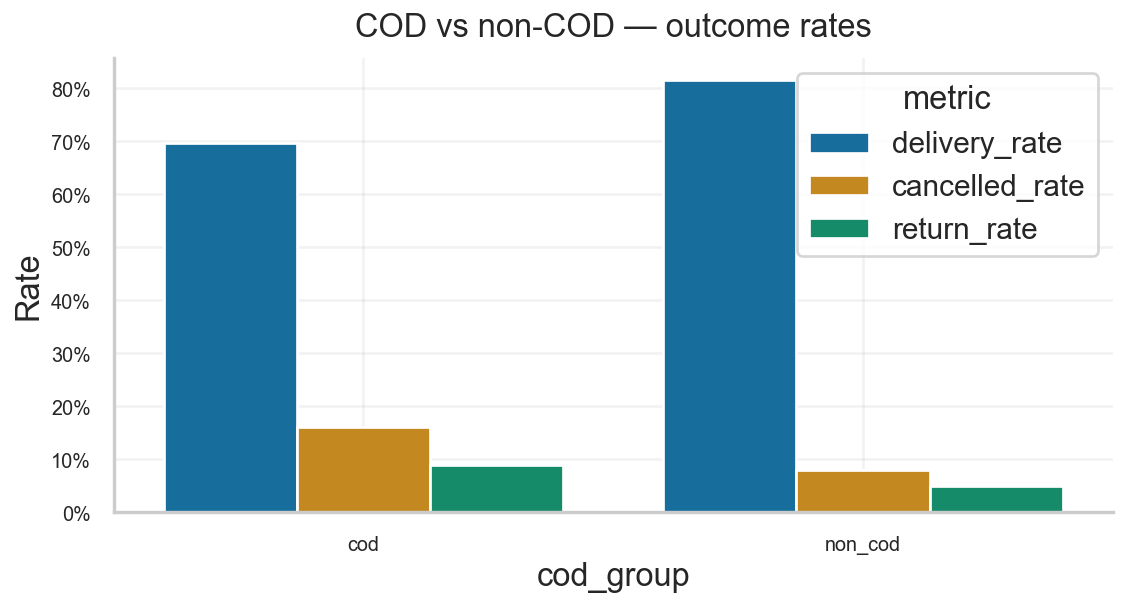

In [79]:
# 4) COD risk check: COD vs non-COD
if orders_enriched is not None:
    cod = orders_enriched.copy()
    cod["cod_group"] = np.where(cod["payment_method"] == "cod", "cod", "non_cod")

    cod_mix = (
        cod.assign(
            delivered_flag=(cod["order_status"] == "delivered").astype(int),
            cancelled_flag=(cod["order_status"] == "cancelled").astype(int),
            returned_flag=(cod["order_status"] == "returned").astype(int),
        )
        .groupby("cod_group", as_index=False)
        .agg(
            orders=("order_id", "nunique"),
            delivery_rate=("delivered_flag", "mean"),
            cancelled_rate=("cancelled_flag", "mean"),
            return_rate=("returned_flag", "mean"),
        )
    )
    display_4dp(cod_mix)

    cod_long = cod_mix.melt(
        id_vars=["cod_group", "orders"],
        value_vars=["delivery_rate", "cancelled_rate", "return_rate"],
        var_name="metric",
        value_name="rate",
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=cod_long, x="cod_group", y="rate", hue="metric", ax=ax)
    ax.set_title("COD vs non-COD — outcome rates")
    ax.set_xlabel("cod_group")
    ax.set_ylabel("Rate")
    ax.yaxis.set_major_formatter(PCT_FMT_0)
    beautify_ax(ax)
    plt.tight_layout()
    plt.savefig(fig_dir / "multivar_cod_vs_noncod_outcomes.png", dpi=160, bbox_inches="tight")
    plt.show()



### Insight
- `cod` là nhóm có chất lượng funnel yếu rõ rệt: `delivery_rate = 69.67%`, thấp hơn mạnh so với `non_cod = 81.66%`; `cancelled_rate = 16.00%`, gấp đôi `non_cod = 8.00%`; `return_rate = 8.92%`, cũng cao hơn đáng kể so với `5.00%`.
- Đây là bằng chứng trực tiếp mạnh nhất trong phần multivariate rằng `cod` là cụm rủi ro chính cho cả `cancel` lẫn `return`, không chỉ là một giả thuyết từ biểu đồ phân phối ban đầu.
- Hàm ý KPI: nếu cần chọn một điểm can thiệp ưu tiên để cải thiện health funnel, `cod` là ứng viên số 1.
- Liên hệ với [ORDER.md](/Users/tawannt/Study/Competition/Datathon/VinUni/ORDER.md): phần leak trước delivery trước đó đã thấy ở level tổng quan; cell này chỉ ra cụ thể leak đó tập trung mạnh ở nhóm COD.


,traffic_source,total_sessions,total_orders,total_delivered,orders_per_session,delivered_per_session
0,organic_search,27196976,50534.0000,40341.0000,0.0021,0.0016
1,paid_search,19598271,29203.0000,23322.0000,0.0016,0.0013
2,social_media,15816226,21999.0000,17644.0000,0.0015,0.0012


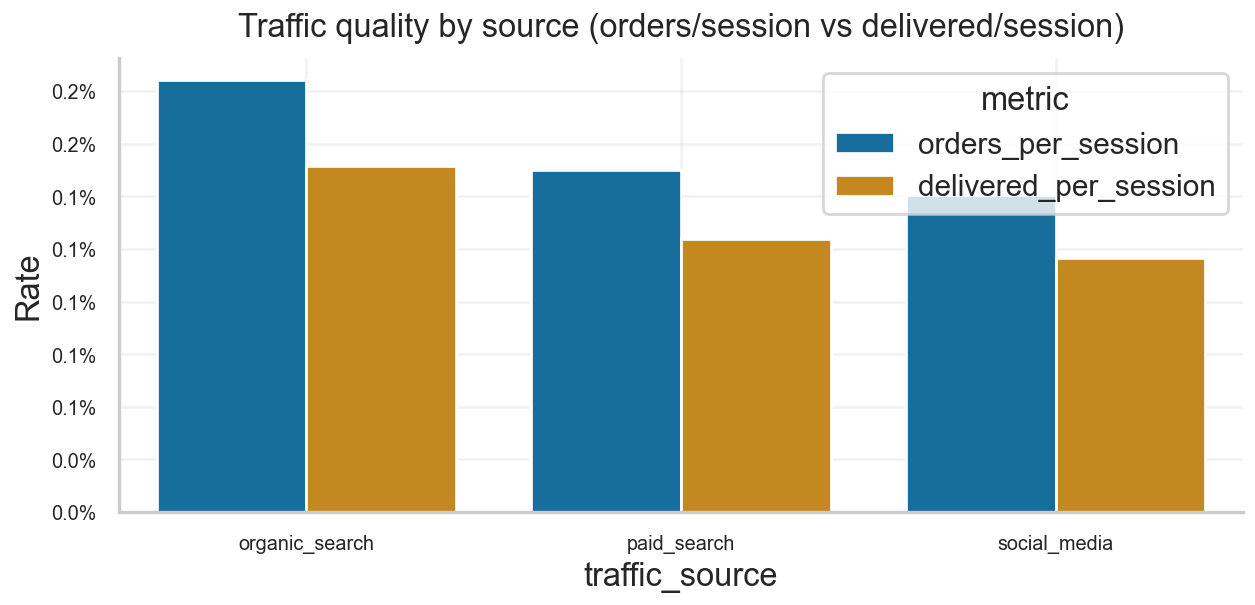

In [80]:
# 5) Traffic quality: sessions -> orders -> delivered
if web_traffic is not None and {"date", "traffic_source", "sessions"}.issubset(web_traffic.columns):
    candidate_sources = [
        s for s in ["organic_search", "paid_search", "social_media"]
        if s in set(orders_enriched["order_source"].dropna().unique())
    ]

    orders_daily = orders_enriched[orders_enriched["order_source"].isin(candidate_sources)].copy()
    orders_daily["delivered_flag"] = (orders_daily["order_status"] == "delivered").astype(int)

    ord_src_day = (
        orders_daily.groupby(["order_date", "order_source"], as_index=False)
        .agg(
            orders=("order_id", "nunique"),
            delivered_orders=("delivered_flag", "sum"),
        )
        .rename(columns={"order_source": "traffic_source", "order_date": "date"})
    )

    traffic_day = (
        web_traffic[web_traffic["traffic_source"].isin(candidate_sources)]
        .groupby(["date", "traffic_source"], as_index=False)
        .agg(sessions=("sessions", "sum"))
    )

    quality = traffic_day.merge(ord_src_day, on=["date", "traffic_source"], how="left").fillna({"orders": 0, "delivered_orders": 0})
    quality["orders_per_session"] = np.where(quality["sessions"] > 0, quality["orders"] / quality["sessions"], np.nan)
    quality["delivered_per_session"] = np.where(quality["sessions"] > 0, quality["delivered_orders"] / quality["sessions"], np.nan)

    quality_summary = (
        quality.groupby("traffic_source", as_index=False)
        .agg(
            total_sessions=("sessions", "sum"),
            total_orders=("orders", "sum"),
            total_delivered=("delivered_orders", "sum"),
            orders_per_session=("orders_per_session", "mean"),
            delivered_per_session=("delivered_per_session", "mean"),
        )
        .sort_values("total_orders", ascending=False)
    )
    display_4dp(quality_summary)

    q_long = quality_summary.melt(
        id_vars=["traffic_source"],
        value_vars=["orders_per_session", "delivered_per_session"],
        var_name="metric",
        value_name="rate",
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=q_long, x="traffic_source", y="rate", hue="metric", ax=ax)
    ax.set_title("Traffic quality by source (orders/session vs delivered/session)")
    ax.set_xlabel("traffic_source")
    ax.set_ylabel("Rate")
    ax.yaxis.set_major_formatter(PCT_FMT_1)
    beautify_ax(ax)
    plt.tight_layout()
    plt.savefig(fig_dir / "multivar_traffic_quality_orders_delivered_per_session.png", dpi=160, bbox_inches="tight")
    plt.show()



### Insight
- `organic_search` dẫn đầu cả volume và chất lượng traffic trong 3 nguồn được map trực tiếp với `web_traffic`: `orders/session = 0.21%`, `delivered/session = 0.16%`, cao hơn `paid_search` và `social_media`.
- `paid_search` đứng thứ hai (`0.16%` orders/session; `0.13%` delivered/session), còn `social_media` thấp nhất (`0.15%`; `0.12%`). Thứ hạng này nhất quán cả ở đầu funnel (orders) lẫn cuối funnel (delivered).
- Khoảng cách giữa `orders/session` và `delivered/session` không đảo thứ hạng kênh, nên vấn đề không chỉ là volume traffic mà còn là chất lượng traffic đi xuyên suốt funnel.
- Hàm ý business: nếu tối ưu acquisition theo chất lượng đơn hoàn tất, `organic_search` đang là benchmark tốt nhất; `paid_search` và `social_media` cần được đánh giá theo delivered efficiency, không chỉ theo order volume.


## 5. Multi / Time series / Geography

### Time series (theo `DATA.md`)
- So sánh xu hướng `daily_kpis.net_revenue` với `sales.Revenue` (nếu khớp).
- Kiểm tra tính mùa vụ theo **tháng/tuần**.
- Kết hợp `web_traffic` theo ngày để tìm **leading indicators** (sessions/visitors → orders/revenue).

### Geography
- So sánh đơn hàng/doanh thu theo `region`/`city` để tìm thị trường trọng điểm.

> Gợi ý chấm điểm: Mỗi insight time-series/geography nên có “hành động” (ví dụ phân bổ marketing, tối ưu tồn kho theo vùng, SLA giao hàng).


Time series — daily KPIs


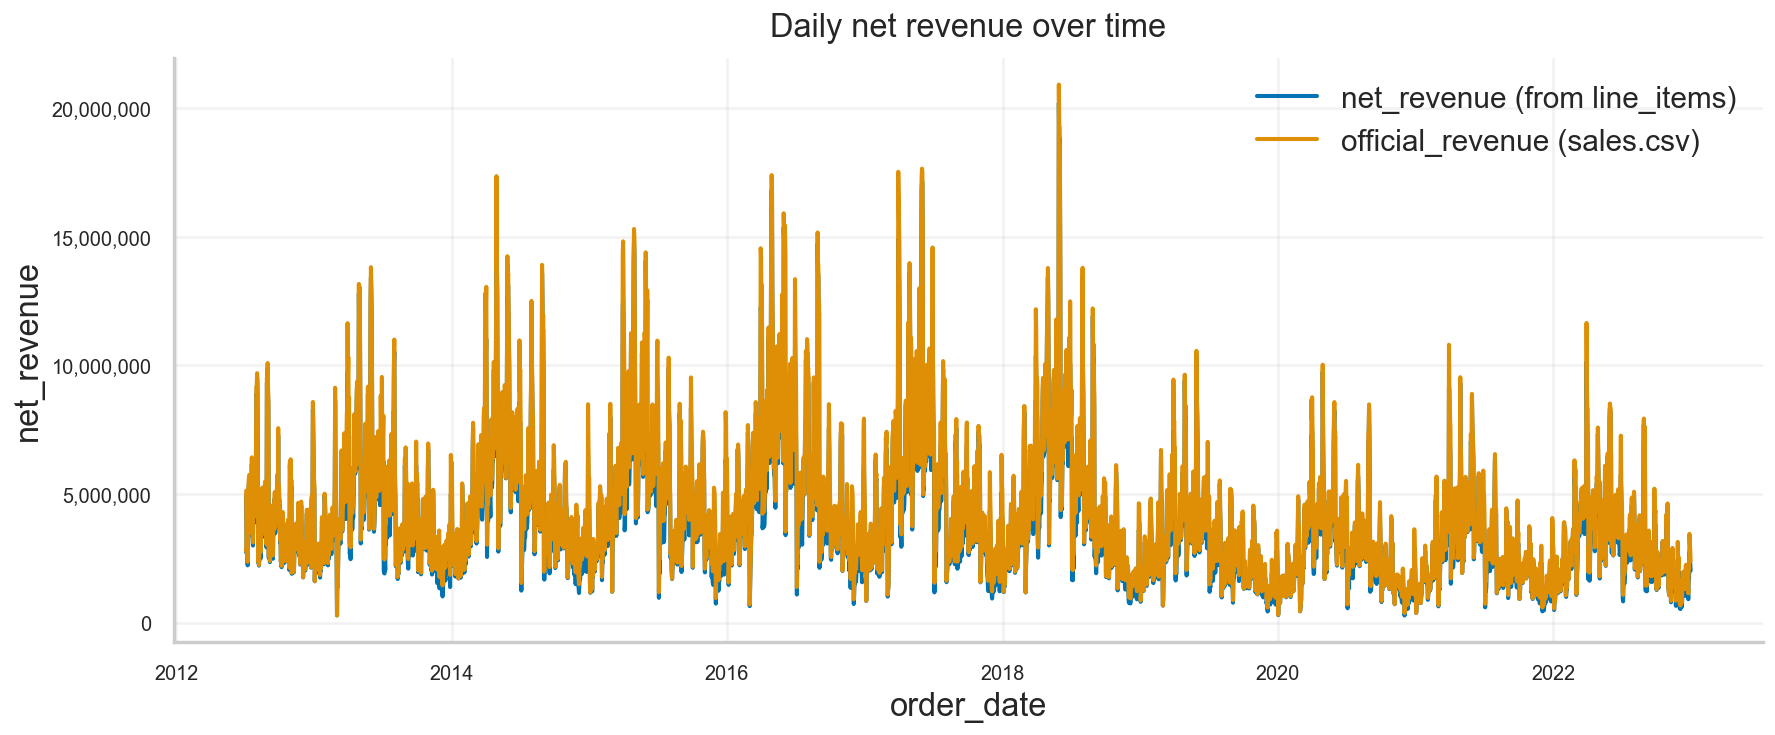

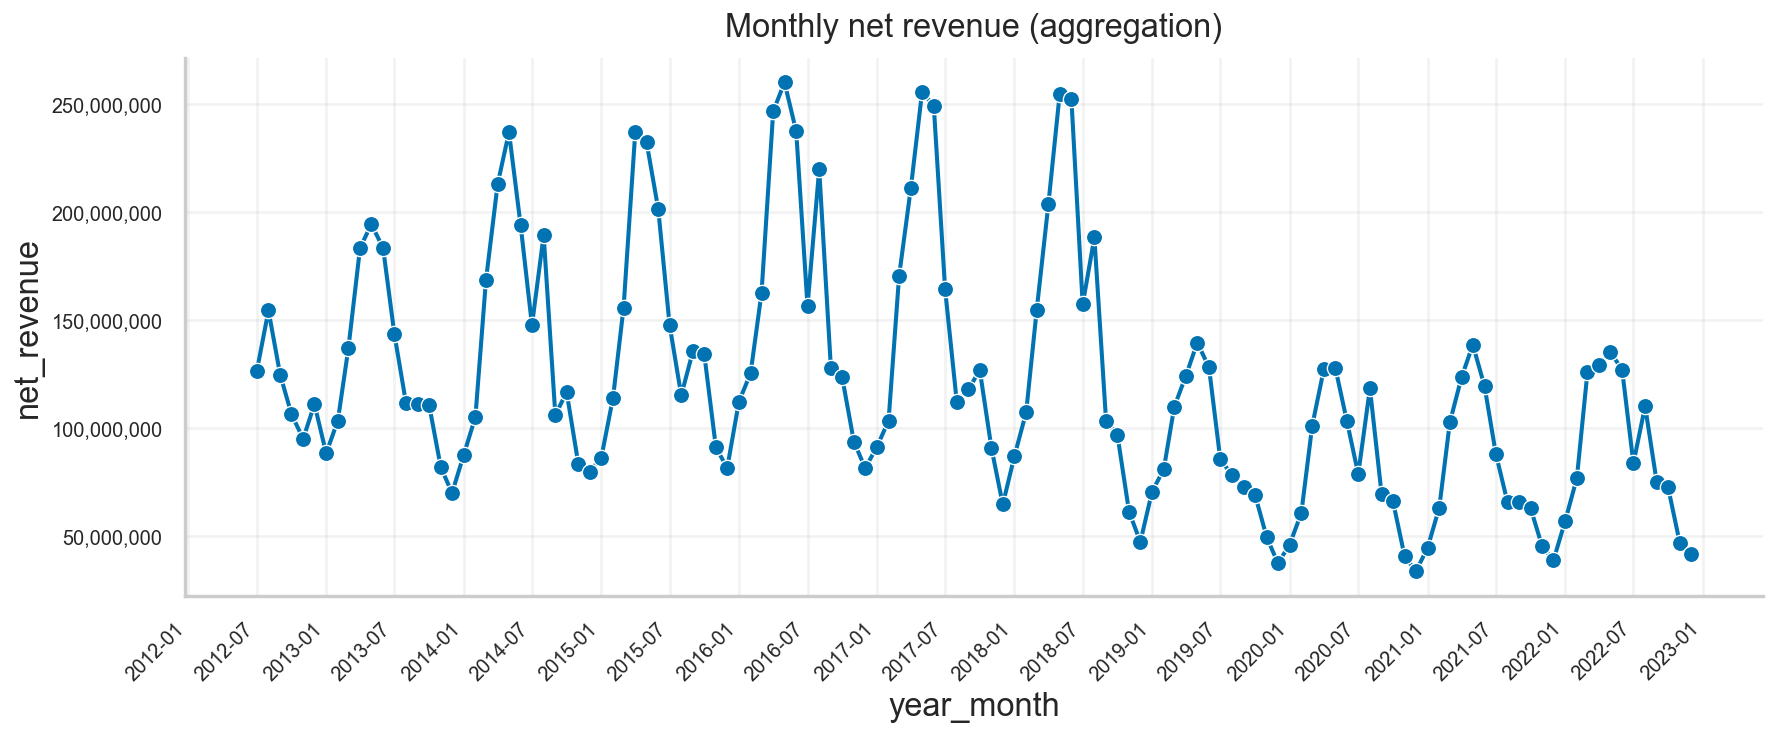


Time series — web traffic as leading indicator
Pearson corr(sessions, net_revenue) = 0.328


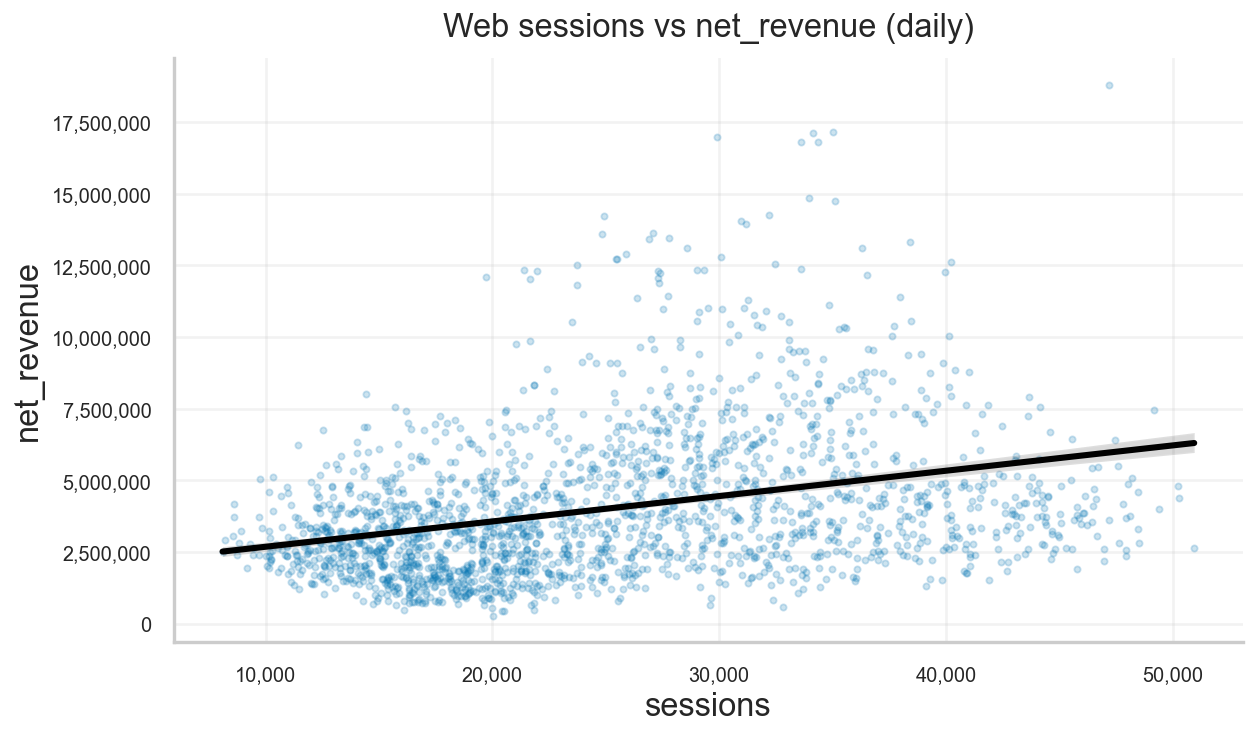

Saved merged daily KPIs + traffic to: outputs/daily_kpis_with_traffic.csv

Geography — orders/revenue by region


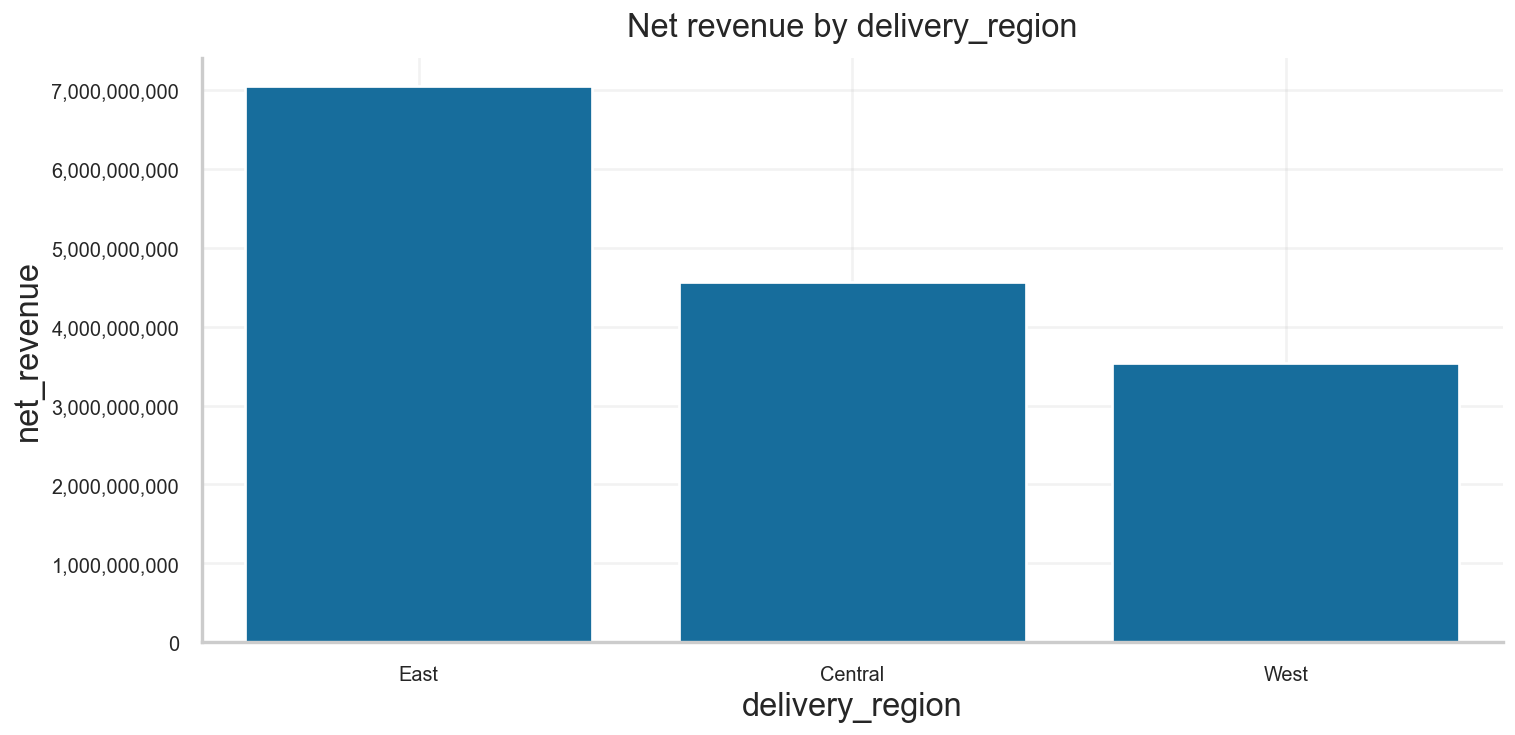

Saved region KPIs to: outputs/region_kpis.csv


,delivery_region,orders,net_revenue,gross_profit
1,East,294612,7055611380.17,460108864.66
0,Central,184691,4568104169.46,291673832.69
2,West,167642,3546493396.21,254975729.36


In [81]:
print_section("Time series — daily KPIs")

# Recompute daily_kpis if not present (safe for re-runs)
if "daily_kpis" not in globals() and line_items is not None and "order_date" in line_items.columns:
    daily_kpis = (
        line_items.groupby("order_date")
        .agg(
            orders=("order_id", "nunique"),
            units=("quantity", "sum"),
            net_revenue=("net_revenue", "sum"),
        )
        .reset_index()
        .sort_values("order_date")
    )

if "daily_kpis" in globals():
    fig, ax1 = plt.subplots(figsize=(14, 6))

    sns.lineplot(data=daily_kpis, x="order_date", y="net_revenue", ax=ax1, label="net_revenue (from line_items)")
    ax1.set_title("Daily net revenue over time")
    ax1.set_xlabel("order_date")
    ax1.set_ylabel("net_revenue")
    format_axis_thousands(ax1, axis="y")

    # Overlay official revenue if available
    if "official_revenue" in daily_kpis.columns and daily_kpis["official_revenue"].notna().any():
        sns.lineplot(data=daily_kpis, x="order_date", y="official_revenue", ax=ax1, label="official_revenue (sales.csv)")
        ax1.legend(frameon=False)

    beautify_ax(ax1)
    plt.tight_layout()
    plt.show()

    # Seasonality view: monthly aggregation (clean x-axis)
    monthly = daily_kpis.copy()
    monthly["year_month"] = monthly["order_date"].dt.to_period("M").dt.to_timestamp()
    monthly = monthly.groupby("year_month").agg(net_revenue=("net_revenue", "sum"), orders=("orders", "sum")).reset_index()

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.lineplot(data=monthly, x="year_month", y="net_revenue", marker="o", ax=ax)
    ax.set_title("Monthly net revenue (aggregation)")
    ax.set_xlabel("year_month")
    ax.set_ylabel("net_revenue")
    format_axis_thousands(ax, axis="y")
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45, ha="right")
    beautify_ax(ax)
    plt.tight_layout()
    plt.show()

print_section("Time series — web traffic as leading indicator")

if (web_traffic is not None) and ("daily_kpis" in globals()):
    # Aggregate web traffic by date
    traffic_daily = (
        web_traffic.groupby("date")
        .agg(
            sessions=("sessions", "sum"),
            unique_visitors=("unique_visitors", "sum"),
            page_views=("page_views", "sum"),
            bounce_rate=("bounce_rate", "mean"),
        )
        .reset_index()
        .rename(columns={"date": "order_date"})
    )

    traffic_merged = daily_kpis.merge(traffic_daily, on="order_date", how="left")

    # Quick correlation (sessions vs revenue)
    if traffic_merged[["sessions", "net_revenue"]].dropna().shape[0] > 10:
        corr = traffic_merged["sessions"].corr(traffic_merged["net_revenue"], method="pearson")
        print(f"Pearson corr(sessions, net_revenue) = {corr:.3f}")

        scatter_df = traffic_merged.dropna(subset=["sessions", "net_revenue"]).copy()
        if len(scatter_df):
            scatter_df = scatter_df.sample(min(len(scatter_df), 2000), random_state=42)

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.regplot(
            data=scatter_df,
            x="sessions",
            y="net_revenue",
            scatter_kws={"alpha": 0.2, "s": 12},
            line_kws={"color": "black"},
            ax=ax,
        )
        ax.set_title("Web sessions vs net_revenue (daily)")
        ax.set_xlabel("sessions")
        ax.set_ylabel("net_revenue")
        format_axis_thousands(ax, axis="both")
        beautify_ax(ax)
        plt.tight_layout()
        plt.show()

    merged_path = OUTPUT_DIR / "daily_kpis_with_traffic.csv"
    traffic_merged.to_csv(merged_path, index=False)
    print(f"Saved merged daily KPIs + traffic to: {merged_path}")

print_section("Geography — orders/revenue by region")

if line_items is not None and {"delivery_region", "net_revenue"}.issubset(line_items.columns):
    region_kpis = (
        line_items.groupby("delivery_region", dropna=False)
        .agg(
            orders=("order_id", "nunique"),
            net_revenue=("net_revenue", "sum"),
            gross_profit=("gross_profit", "sum") if "gross_profit" in line_items.columns else ("net_revenue", "sum"),
        )
        .reset_index()
        .sort_values("net_revenue", ascending=False)
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=region_kpis, x="delivery_region", y="net_revenue", ax=ax)
    ax.set_title("Net revenue by delivery_region")
    ax.set_xlabel("delivery_region")
    ax.set_ylabel("net_revenue")
    format_axis_thousands(ax, axis="y")
    beautify_ax(ax)
    plt.tight_layout()
    plt.show()

    region_path = OUTPUT_DIR / "region_kpis.csv"
    region_kpis.to_csv(region_path, index=False)
    print(f"Saved region KPIs to: {region_path}")
    display(region_kpis)

---

# Trả lời câu hỏi trắc nghiệm (question.md)

Phần này trả lời các câu hỏi yêu cầu **tính toán trực tiếp** từ dữ liệu gốc.
Mỗi câu dùng đúng bảng đã load ở phần trên (`orders`, `order_items`, `products`, `returns`, `geography`, `sales`).

> **Lưu ý**: Các derived metrics trong phần này được tính theo công thức đã mô tả trong `DATA.md` Section 5.

## Q1. Median inter-order gap

- **Metric**: Median số ngày giữa 2 lần mua liên tiếp (Inter-order Gap — `DATA.md` Section 5).
- **Dimension**: Group by `customer_id`, sort theo `order_date`.
- **Xử lý**: Time-series diff (`shift` + `dt.days`) → lọc customers >1 order → `median()`.

**Biểu đồ**: Histogram phân phối `gap_days` — cho thấy hình dạng distribution (skewness), vị trí median so với các đáp án. Histogram phù hợp vì đây là biến liên tục cần xem mật độ phân bố.

Median inter-order gap: 144 days
Mean: 285.6 | Std: 389.7 | n=556,699
25th: 46 | 50th: 144 | 75th: 357


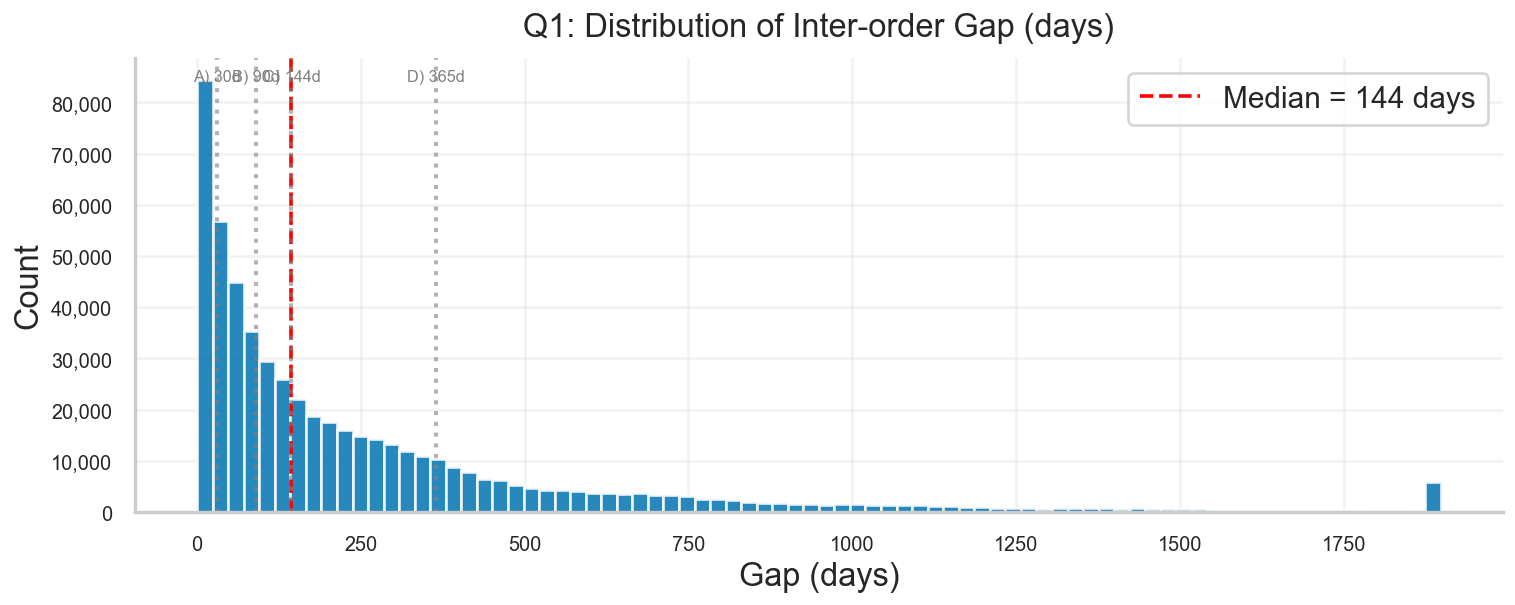

In [82]:
# Q1: Median inter-order gap (days) — customers with >1 order
orders_sorted = orders.sort_values(["customer_id", "order_date"])
orders_sorted["prev_order_date"] = orders_sorted.groupby("customer_id")["order_date"].shift(1)
orders_sorted["gap_days"] = (orders_sorted["order_date"] - orders_sorted["prev_order_date"]).dt.days

gaps = orders_sorted["gap_days"].dropna()
median_gap = gaps.median()

print(f"Median inter-order gap: {median_gap:.0f} days")
print(f"Mean: {gaps.mean():.1f} | Std: {gaps.std():.1f} | n={len(gaps):,}")
print(f"25th: {gaps.quantile(0.25):.0f} | 50th: {gaps.quantile(0.5):.0f} | 75th: {gaps.quantile(0.75):.0f}")

# Histogram
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(gaps.clip(upper=gaps.quantile(0.99)), bins=80, edgecolor="white", alpha=0.85)
ax.axvline(median_gap, color="red", ls="--", lw=2, label=f"Median = {median_gap:.0f} days")
for val, label in [(30, "A) 30d"), (90, "B) 90d"), (144, "C) 144d"), (365, "D) 365d")]:
    ax.axvline(val, color="gray", ls=":", alpha=0.6)
    ax.text(val, ax.get_ylim()[1]*0.95, label, ha="center", fontsize=9, color="gray")
ax.set_title("Q1: Distribution of Inter-order Gap (days)")
ax.set_xlabel("Gap (days)")
ax.set_ylabel("Count")
ax.legend()
format_axis_thousands(ax, axis="y")
beautify_ax(ax)
plt.tight_layout()
plt.show()

## Q3. Return reason phổ biến nhất — Streetwear

- **Metric**: Count số records trong `returns` (đếm dòng, không phải `return_quantity`).
- **Dimension**: `return_reason`, sau khi filter `category == 'Streetwear'`.
- **Xử lý**: Join `returns` ↔ `products` on `product_id` → filter category → `value_counts()`.

**Biểu đồ**: Horizontal bar chart — so sánh rank giữa các categorical values (return reasons). Bar chart ngang dễ đọc label dài hơn countplot dọc.

return_reason
wrong_size          7626
defective           4330
not_as_described    3854
changed_mind        3830
late_delivery       2159
Name: count, dtype: int64[pyarrow]

Most frequent: wrong_size (7,626 records)


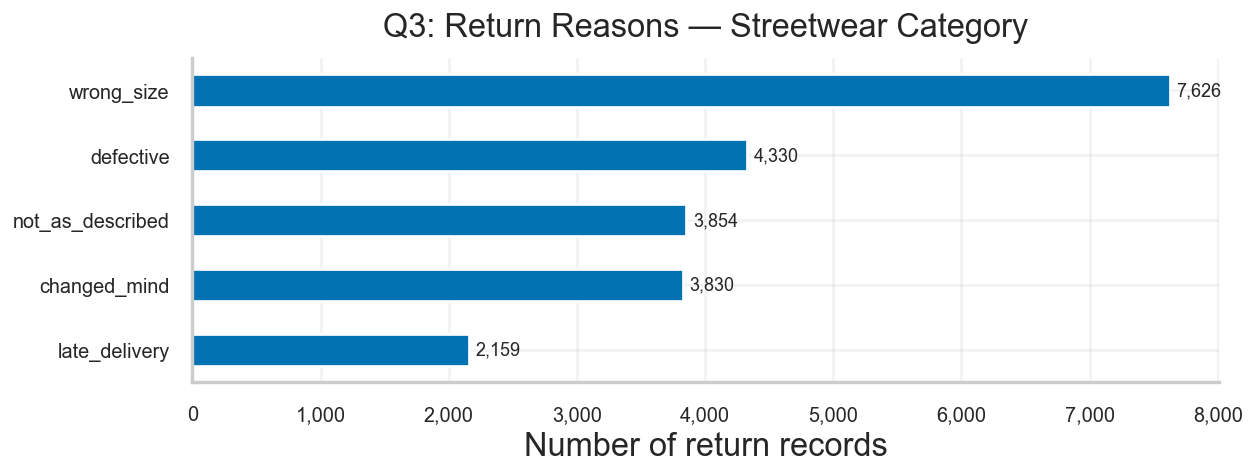

In [83]:
# Q3: Most frequent return reason for Streetwear category
returns_products = returns.merge(products[["product_id", "category"]], on="product_id", how="inner")
streetwear_returns = returns_products[returns_products["category"] == "Streetwear"]

reason_counts = streetwear_returns["return_reason"].value_counts()
print(reason_counts)
print(f"\nMost frequent: {reason_counts.idxmax()} ({reason_counts.max():,} records)")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
reason_counts.sort_values().plot.barh(ax=ax, edgecolor="white")
ax.set_title("Q3: Return Reasons — Streetwear Category")
ax.set_xlabel("Number of return records")
ax.set_ylabel("")
for i, (val, name) in enumerate(zip(reason_counts.sort_values(), reason_counts.sort_values().index)):
    ax.text(val + 50, i, f"{val:,}", va="center", fontsize=10)
format_axis_thousands(ax, axis="x")
beautify_ax(ax)
plt.tight_layout()
plt.show()

## Q5. Promotion application rate

- **Metric**: % rows trong `order_items` có `promo_id` not null (Promotion Application Rate — `DATA.md` Section 5).
- **Dimension**: Không group by — tính tỷ lệ trên toàn bộ bảng.
- **Xử lý**: `notna().mean()` → trả về tỷ lệ trực tiếp.

**Biểu đồ**: Pie chart — thể hiện tỷ lệ phần trăm giữa 2 nhóm (có promo / không promo). Phù hợp khi chỉ có 2 categories part-of-whole.

Total rows: 714,669
Promo applied: 276,316
No promo: 438,353
Promotion application rate: 38.7%


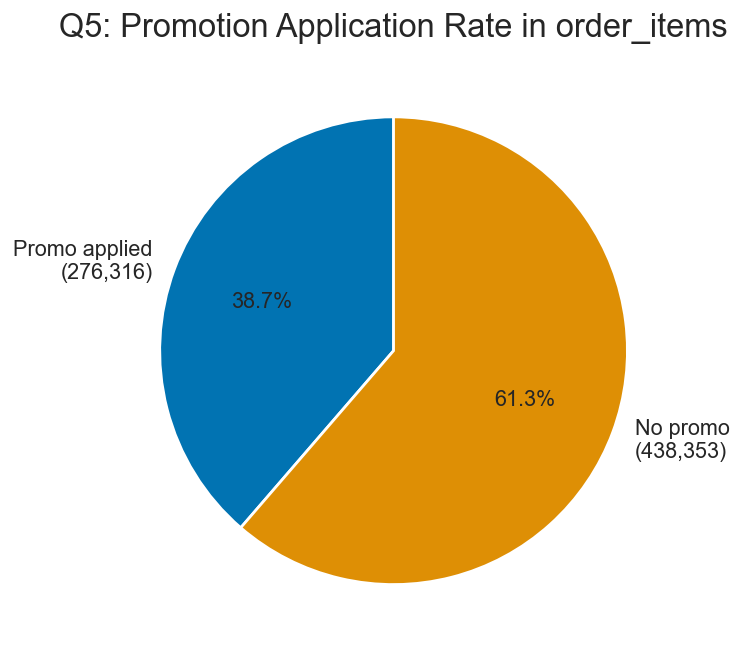

In [84]:
# Q5: % of order_items rows with promo applied
total = len(order_items)
promo_applied = int(order_items["promo_id"].notna().sum())
no_promo = total - promo_applied
pct = promo_applied / total * 100

print(f"Total rows: {total:,}")
print(f"Promo applied: {promo_applied:,}")
print(f"No promo: {no_promo:,}")
print(f"Promotion application rate: {pct:.1f}%")

# Pie chart
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [promo_applied, no_promo],
    labels=[f"Promo applied\n({promo_applied:,})", f"No promo\n({no_promo:,})"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("colorblind", 2),
    textprops={"fontsize": 12},
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Q5: Promotion Application Rate in order_items")
plt.tight_layout()
plt.show()

## Q7. Region có tổng revenue cao nhất (sales_train)

- **Metric**: Tổng `line_revenue = quantity × unit_price − discount_amount` trong giai đoạn training (≤ 2022-12-31).
- **Dimension**: `region` (từ `geography` join qua `orders.zip`).
- **Xử lý**: Join `order_items` → `orders` → `geography` → filter training period → `groupby(region).sum()`.

**Biểu đồ**: Vertical bar chart — so sánh tổng revenue giữa 3 regions. Bar chart dọc phù hợp khi ít categories và cần nhấn mạnh chênh lệch giá trị.

region
East       7,291,150,819
Central    4,719,491,268
West       3,670,227,178
Name: line_revenue, dtype: str

Highest: East (7,291,150,819 VND)


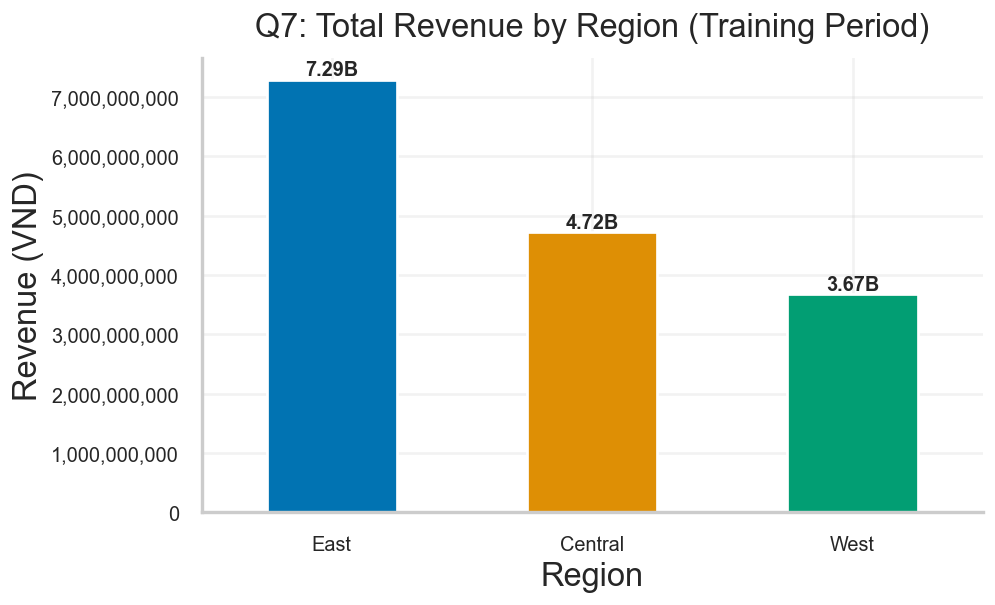

In [85]:
# Q7: Region with highest total revenue (training period)
oi_orders = order_items.merge(orders[["order_id", "order_date", "zip"]], on="order_id", how="inner")
oi_orders = oi_orders[oi_orders["order_date"] <= "2022-12-31"]  # sales_train only

oi_geo = oi_orders.merge(geography[["zip", "region"]], on="zip", how="inner")
oi_geo["line_revenue"] = oi_geo["quantity"] * oi_geo["unit_price"] - oi_geo["discount_amount"]

region_revenue = oi_geo.groupby("region")["line_revenue"].sum().sort_values(ascending=False)
print(region_revenue.apply(lambda x: f"{x:,.0f}"))
print(f"\nHighest: {region_revenue.idxmax()} ({region_revenue.max():,.0f} VND)")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
region_revenue.plot.bar(ax=ax, edgecolor="white", color=sns.color_palette("colorblind", 3))
for i, (region, val) in enumerate(region_revenue.items()):
    ax.text(i, val + region_revenue.max()*0.01, f"{val/1e9:.2f}B", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Q7: Total Revenue by Region (Training Period)")
ax.set_xlabel("Region")
ax.set_ylabel("Revenue (VND)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
format_axis_thousands(ax, axis="y")
beautify_ax(ax)
plt.tight_layout()
plt.show()

## Q9. Size có return rate cao nhất

- **Metric**: Return rate = số records trong `returns` / số rows trong `order_items`, tính theo `size` (`DATA.md` Section 5).
- **Dimension**: `size` (join cả `returns` và `order_items` với `products` on `product_id`).
- **Xử lý**: Group by `size` → đếm riêng returns và order_items → chia tỷ lệ.

**Biểu đồ**: Grouped bar chart (return count & order_items count) + line overlay (return rate %). Grouped bar cho thấy cả volume lẫn tỷ lệ — tránh kết luận sai khi chỉ nhìn rate mà bỏ qua sample size.

      return_count  oi_count  return_rate
size                                     
S             9723    172042         0.06
L             9741    173174         0.06
M             9820    176428         0.06
XL           10655    193025         0.06

Highest return rate: S (5.65%)


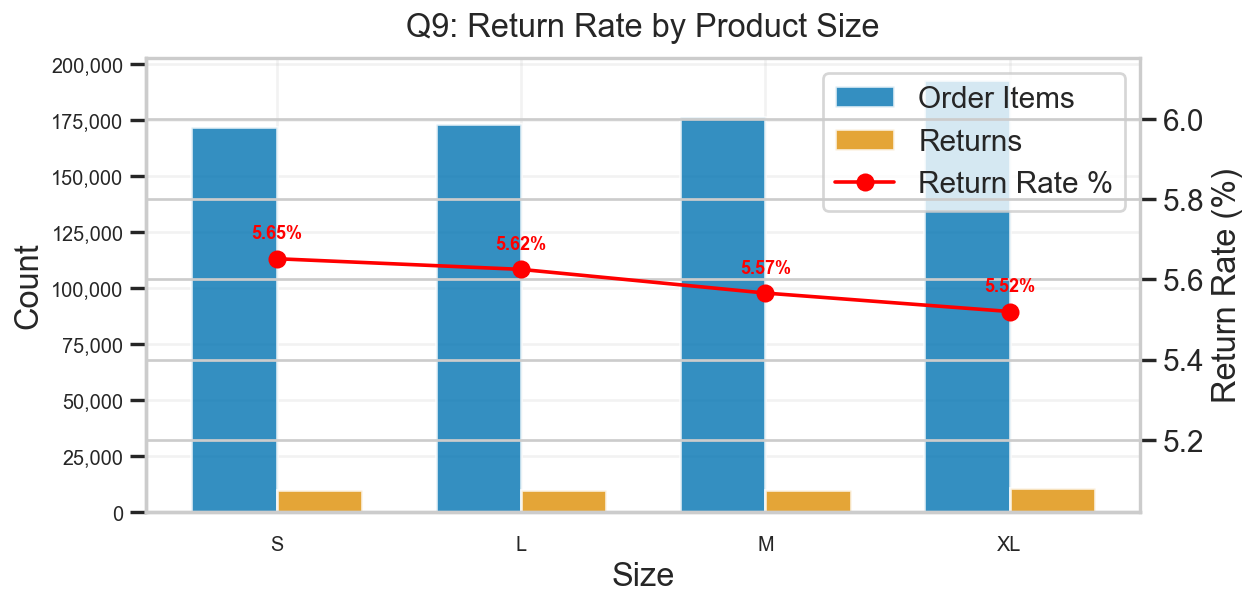

In [86]:
# Q9: Return rate by product size
returns_with_size = returns.merge(products[["product_id", "size"]], on="product_id", how="inner")
returns_by_size = returns_with_size.groupby("size").size().rename("return_count")

oi_with_size = order_items.merge(products[["product_id", "size"]], on="product_id", how="inner")
oi_by_size = oi_with_size.groupby("size").size().rename("oi_count")

rate = pd.concat([returns_by_size, oi_by_size], axis=1)
rate["return_rate"] = rate["return_count"] / rate["oi_count"]
rate = rate.sort_values("return_rate", ascending=False)

print(rate)
print(f"\nHighest return rate: {rate['return_rate'].idxmax()} "
      f"({rate['return_rate'].max()*100:.2f}%)")

# Visualization: bars (counts) + line (rate)
fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(rate))
w = 0.35

ax1.bar(x - w/2, rate["oi_count"], w, label="Order Items", alpha=0.8, edgecolor="white")
ax1.bar(x + w/2, rate["return_count"], w, label="Returns", alpha=0.8, edgecolor="white")
ax1.set_xlabel("Size")
ax1.set_ylabel("Count")
ax1.set_xticks(x)
ax1.set_xticklabels(rate.index)
format_axis_thousands(ax1, axis="y")

ax2 = ax1.twinx()
ax2.plot(x, rate["return_rate"] * 100, color="red", marker="o", lw=2, label="Return Rate %")
for i, v in enumerate(rate["return_rate"]):
    ax2.text(i, v*100 + 0.05, f"{v*100:.2f}%", ha="center", fontsize=10, color="red", fontweight="bold")
ax2.set_ylabel("Return Rate (%)")
ax2.set_ylim(rate["return_rate"].min()*100 - 0.5, rate["return_rate"].max()*100 + 0.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Q9: Return Rate by Product Size")
beautify_ax(ax1)
plt.tight_layout()
plt.show()